# SiCASA — Train & Evaluate ResNet50 (Image Classification)
### Pembanding untuk YOLOv8s (Object Detection)

**Dataset:** Cataract vs Normal (3144 gambar, 2 kelas)  
**Split:** Train 2200 / Val 629 / Test 315  
**Model:** ResNet50 (pretrained IMAGENET1K_V1)

## 1. Imports

In [ ]:
import os
import sys
import json
import time
import random
import shutil
import warnings
from pathlib import Path
from collections import Counter
from io import BytesIO
import hashlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, cohen_kappa_score, log_loss,
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, average_precision_score, roc_auc_score
)
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance as sk_permutation_importance
import joblib
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
from tqdm import tqdm

warnings.filterwarnings('ignore')
print("All imports successful!")

All imports successful!


## 2. Konfigurasi

In [ ]:
PROJECT_ROOT = Path.cwd()
DATASET_DIR = PROJECT_ROOT / "dataset"
LABELS_DIR = DATASET_DIR / "labels"
IMAGES_DIR = DATASET_DIR / "images"
APP_DIR = PROJECT_ROOT / "app"
YOLO_WEIGHTS = APP_DIR / "best.pt"
RUNS_DIR = PROJECT_ROOT / "runs" / "resnet50"
PLOTS_DIR = RUNS_DIR / "plots"
INTERP_DIR = RUNS_DIR / "interpretability"

CLASS_NAMES = {0: "Cataract", 1: "Normal"}
NUM_CLASSES = 2
CLASS_COLORS = {0: "#ef4444", 1: "#22c55e"}

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Hyperparameters (ubah di sini)
EPOCHS = 30
BATCH_SIZE = 32
LR = 0.001
PATIENCE = 7
NUM_WORKERS = 0

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 150,
})
sns.set_palette('husl')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")

Device: cuda
PyTorch: 2.7.1+cu118


## 2b. Data Quality Analysis


  DATA QUALITY & EXPLORATORY DATA ANALYSIS

  [0.1] Collecting file metadata...
      Total images: 3144, Total labels: 3144

  [0.2] Missing Values Check...
      train : 2200 images, 2200 labels | img_no_label=0, label_no_img=0 [OK]
      val   :  629 images,  629 labels | img_no_label=0, label_no_img=0 [OK]
      test  :  315 images,  315 labels | img_no_label=0, label_no_img=0 [OK]

  [0.3] Duplicate Detection (MD5 Hash)...
      Found 12 duplicate groups:
        Hash 23c752d87e36...: ['15_jpg.rf.c3f0dd12ae22ba4a23fd709c5b89edc9.jpg', '15_jpg.rf.6cfb5a67b0c3aa1fc7a1623dbdf3a8af.jpg']
        Hash 1b5a03ee50ad...: ['15_jpg.rf.ce8050420e39c3af56480a6573e19a76.jpg', '15_jpg.rf.b3621035f031dbe8576961b389fa14a1.jpg']
        Hash 96707eb5f174...: ['16_jpg.rf.b1dc1d85d382a40f761750d3566610e2.jpg', '16_jpg.rf.e444816cb4cf3b72618d38ad09339033.jpg']
        Hash 96252cf444b9...: ['18_jpg.rf.37e453b622823a65e22364ea8fc67798.jpg', '18_jpg.rf.9e56957a0d8b539e497e80e0bf5529df.jpg']
        Ha

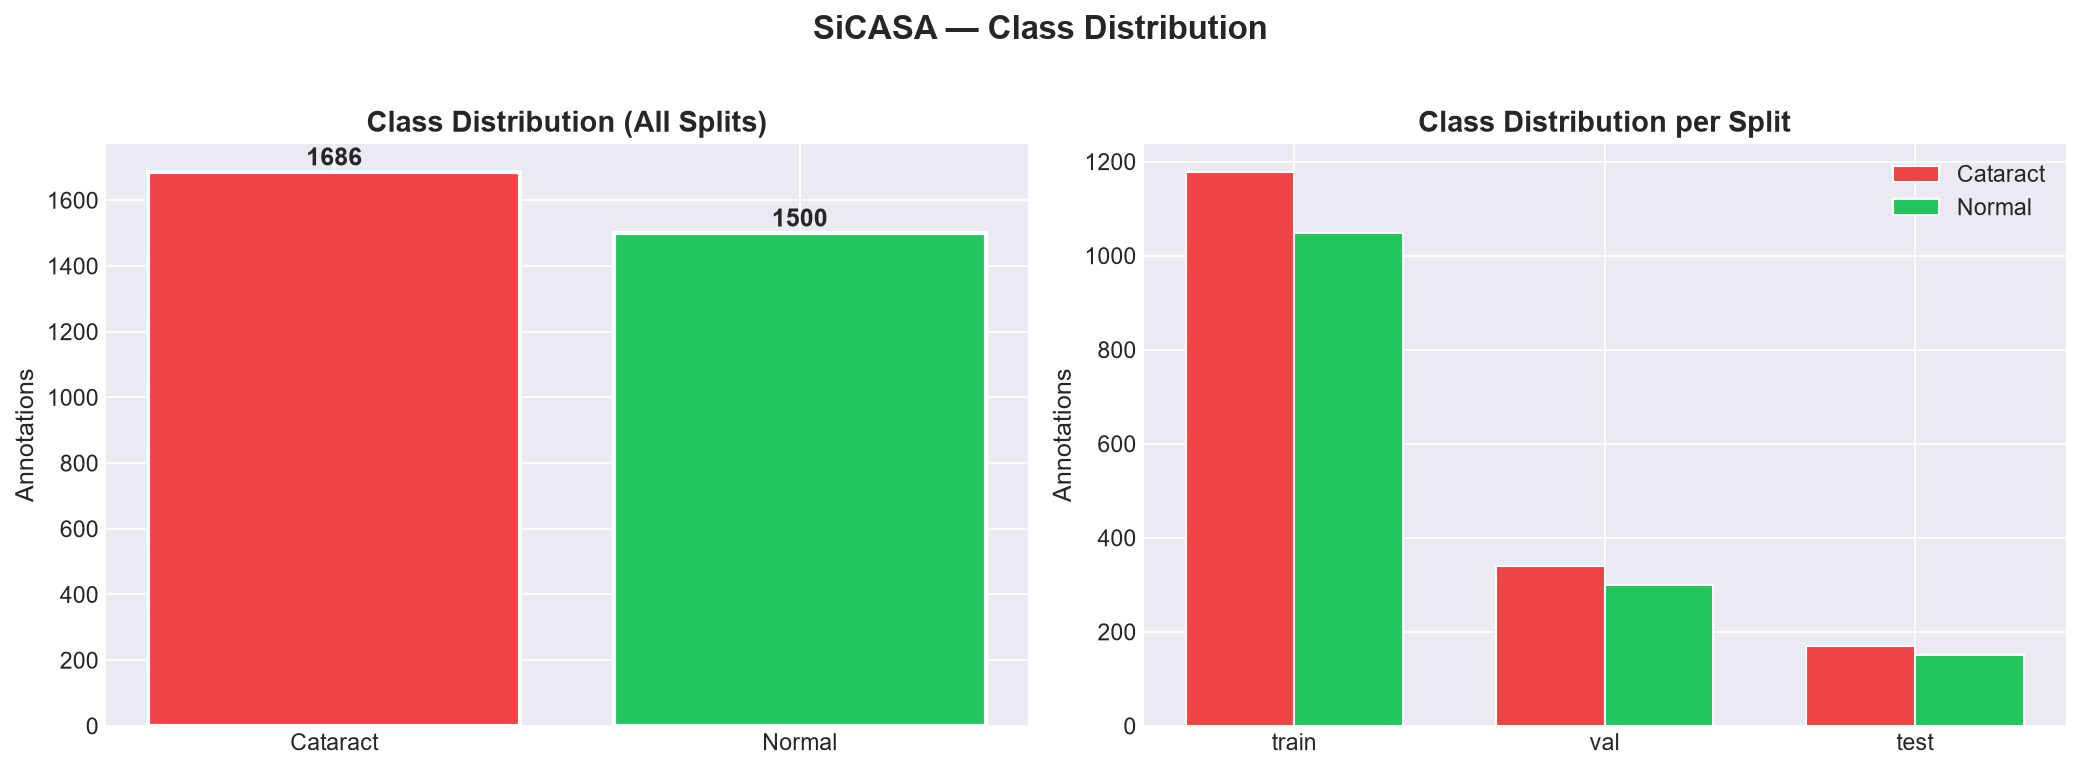

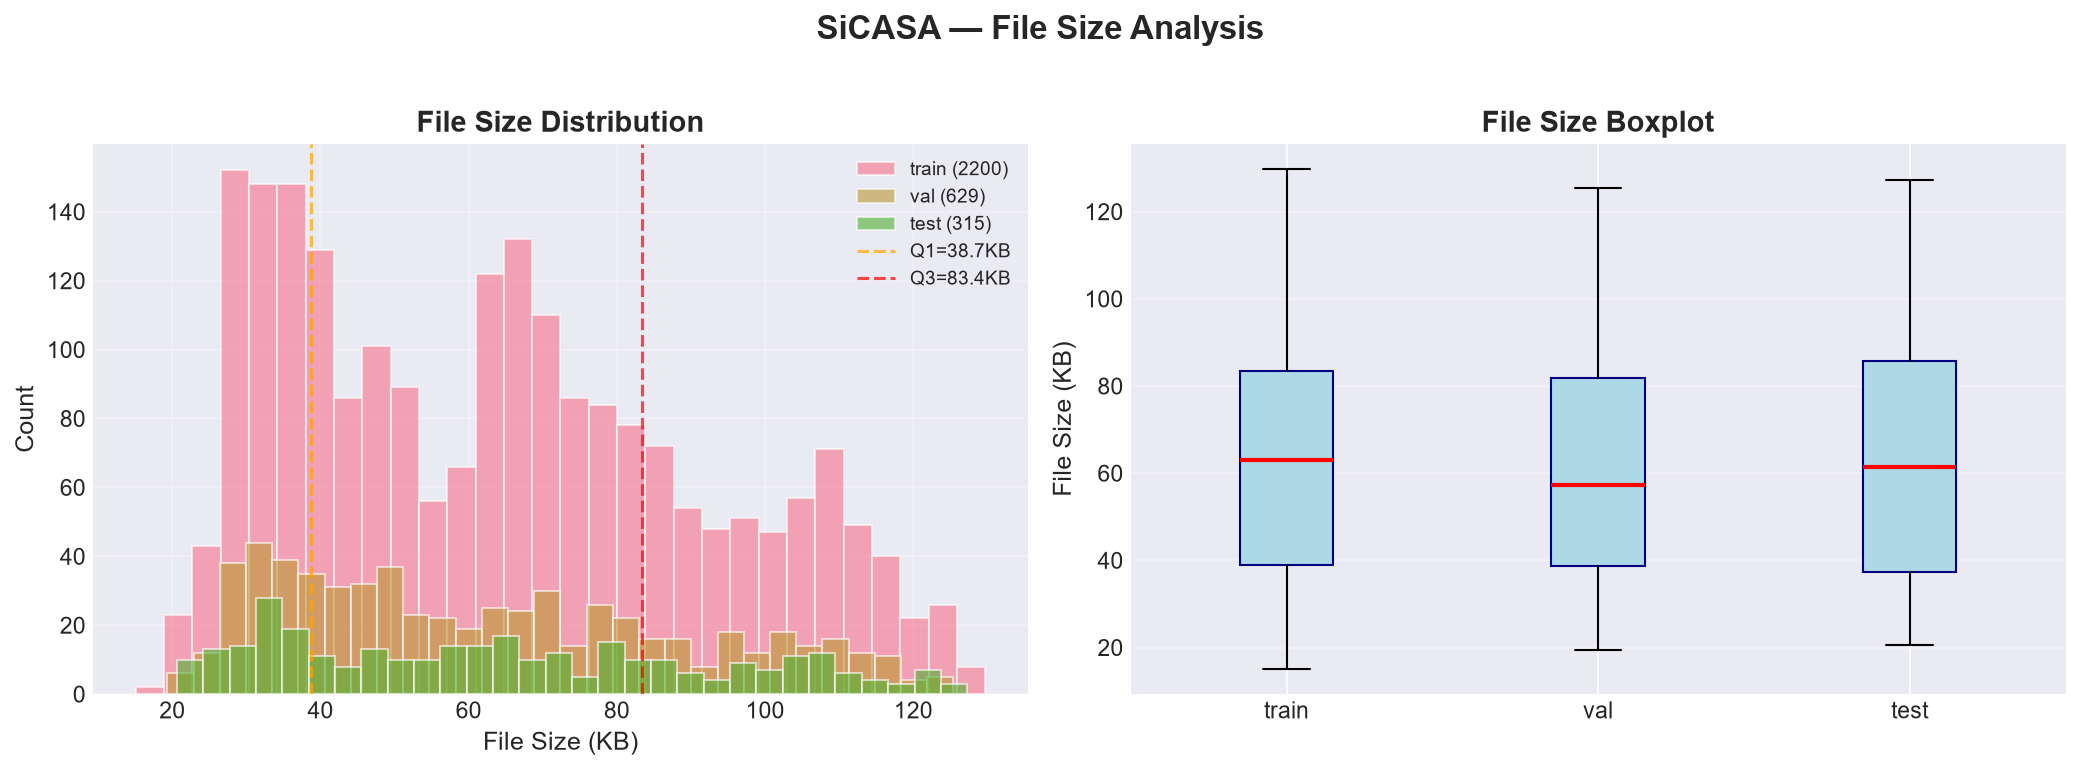

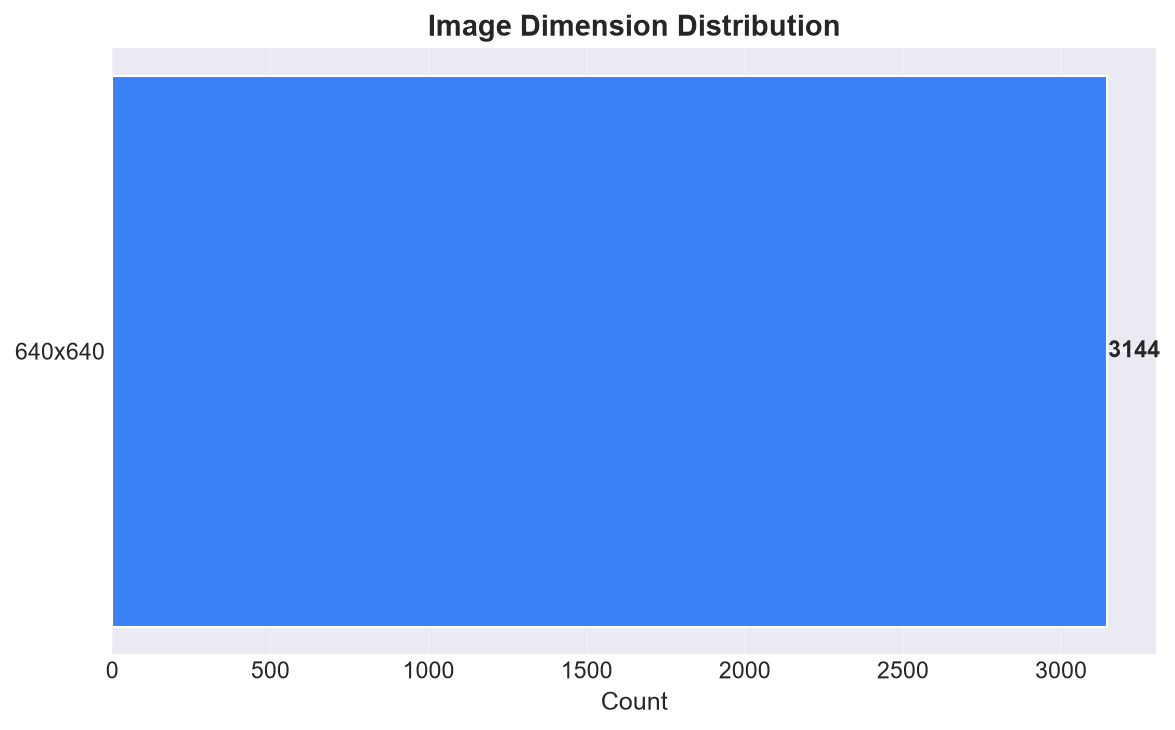

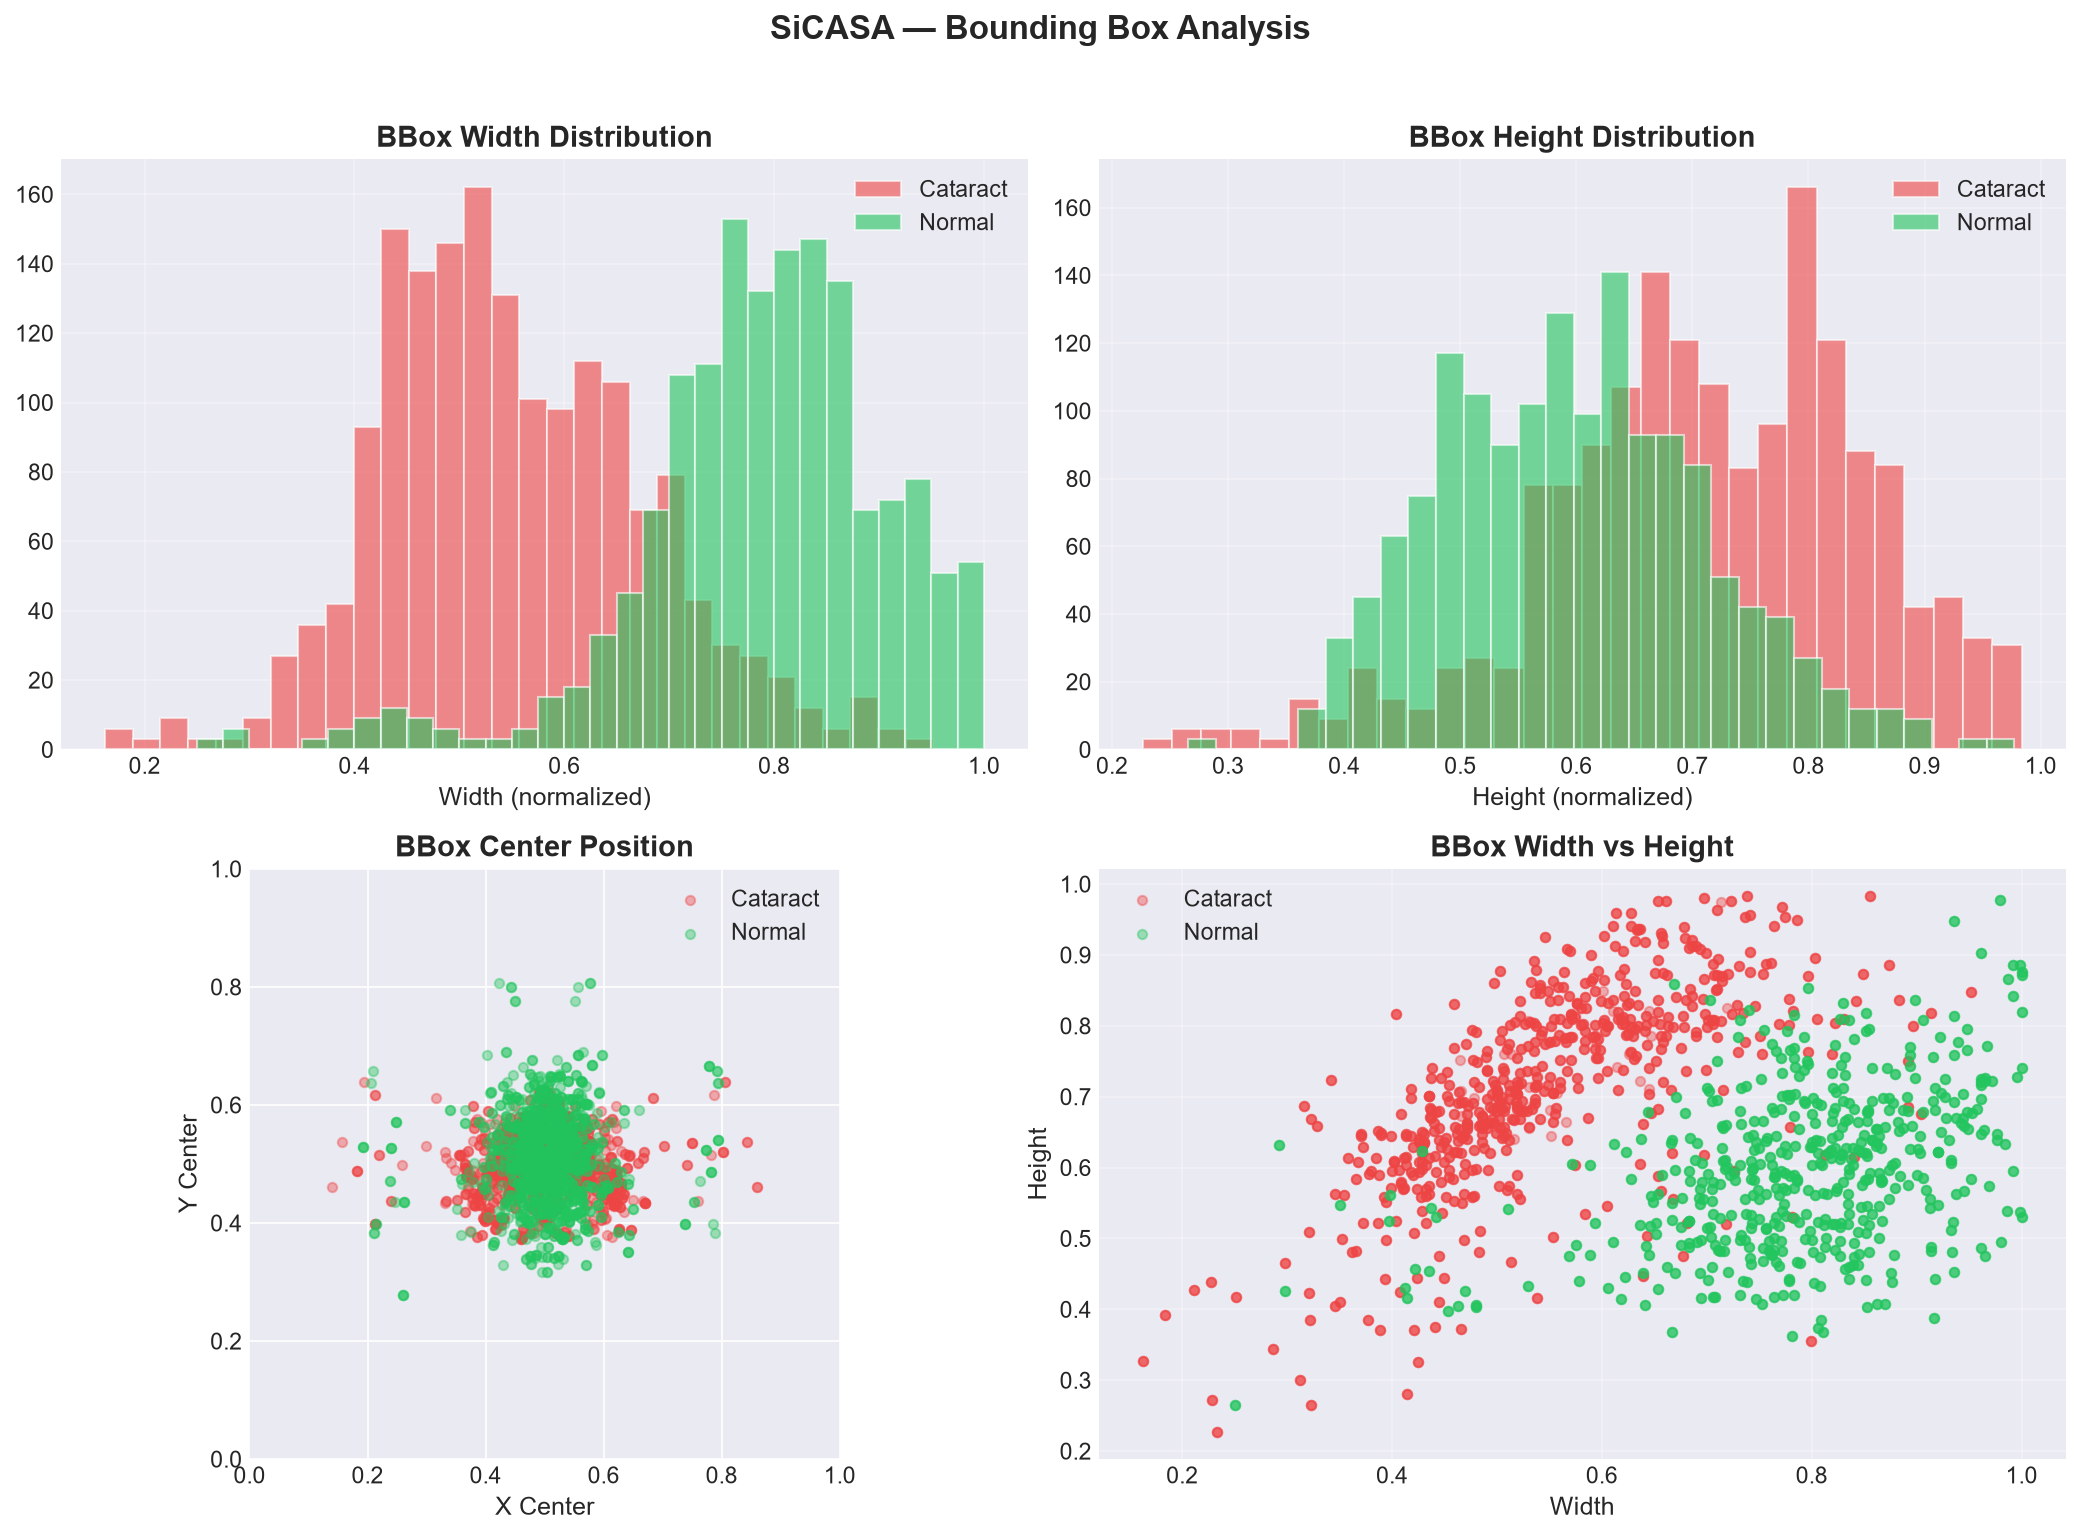

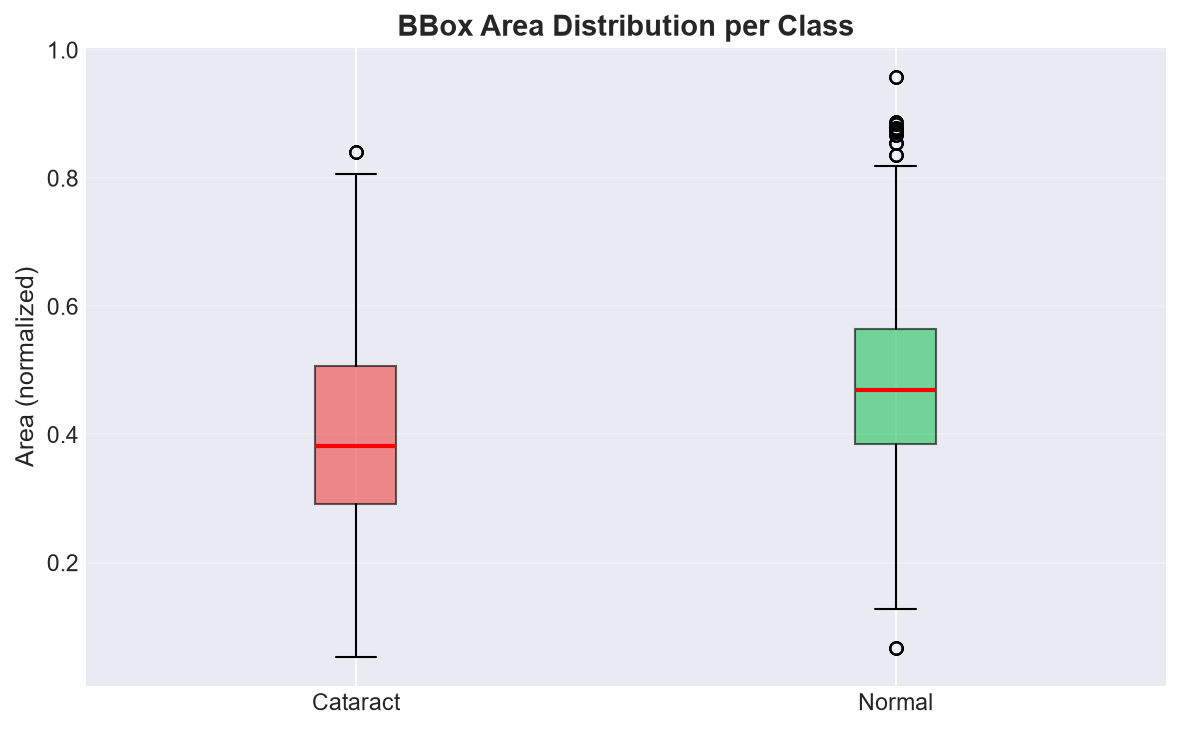


  [0.9] Summary Report...
  DATA QUALITY & EDA REPORT — SiCASA Dataset
  Total Images     : 3144
  Total Labels     : 3144
  Splits           : Train=2200, Val=629, Test=315
  Duplicate Groups : 12
  Size Outliers    : 0
  Label Issues     : 0
  Dimensions       : {(640, 640)}
  File Size Range  : 15.0KB - 129.7KB
  Annotations      : Cataract=1686, Normal=1500

  EDA plots saved to: d:\UDINUS\SEMESTER 4\PEMBELAJARAN MESIN\SiCASA_Project\1. SiCASA\runs\resnet50\eda


In [ ]:
def run_data_quality_and_eda():
    print("\n" + "=" * 60)
    print("  DATA QUALITY & EXPLORATORY DATA ANALYSIS")
    print("=" * 60)
    EDA_DIR = RUNS_DIR / "eda"
    EDA_DIR.mkdir(parents=True, exist_ok=True)

    splits = ['train', 'val', 'test']
    img_ext = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

    all_images = {}
    all_labels = {}
    all_file_sizes = {}
    all_dims = {}
    all_bbox_data = []
    all_class_counts = Counter()
    image_hashes = {}

    # 0.1 Collect Data
    print("\n  [0.1] Collecting file metadata...")
    for split in splits:
        img_dir = IMAGES_DIR / split
        lbl_dir = LABELS_DIR / split
        all_images[split] = []
        all_labels[split] = []
        all_file_sizes[split] = []
        all_dims[split] = []
        if not img_dir.exists():
            continue
        for img_file in sorted(img_dir.iterdir()):
            if img_file.suffix.lower() not in img_ext:
                continue
            all_images[split].append(img_file)
            fsize = img_file.stat().st_size
            all_file_sizes[split].append(fsize)
            try:
                with Image.open(img_file) as im:
                    all_dims[split].append((im.width, im.height))
            except Exception:
                all_dims[split].append((0, 0))
            md5 = hashlib.md5(img_file.read_bytes()).hexdigest()
            if md5 in image_hashes:
                image_hashes[md5].append((split, img_file.name))
            else:
                image_hashes[md5] = [(split, img_file.name)]
            lbl_file = lbl_dir / (img_file.stem + '.txt')
            if lbl_file.exists():
                all_labels[split].append(lbl_file)
                try:
                    text = lbl_file.read_text(encoding='utf-8').strip()
                    for line in text.splitlines():
                        parts = line.strip().split()
                        if len(parts) < 5:
                            continue
                        cls_id = int(parts[0])
                        x_c, y_c, w, h = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                        all_bbox_data.append({
                            'split': split, 'file': img_file.name,
                            'class_id': cls_id, 'x_center': x_c, 'y_center': y_c,
                            'width': w, 'height': h, 'area': w * h
                        })
                        all_class_counts[cls_id] += 1
                except Exception:
                    pass
    total_imgs = sum(len(v) for v in all_images.values())
    total_lbls = sum(len(v) for v in all_labels.values())
    print(f"      Total images: {total_imgs}, Total labels: {total_lbls}")

    # 0.2 Missing Values
    print("\n  [0.2] Missing Values Check...")
    for split in splits:
        img_names = {f.stem for f in all_images[split]}
        lbl_names = {f.stem for f in all_labels[split]}
        imgs_no_lbl = img_names - lbl_names
        lbls_no_img = lbl_names - img_names
        status = "OK" if len(imgs_no_lbl) == 0 and len(lbls_no_img) == 0 else "PROBLEM"
        print(f"      {split:<6}: {len(all_images[split]):>4} images, {len(all_labels[split]):>4} labels | img_no_label={len(imgs_no_lbl)}, label_no_img={len(lbls_no_img)} [{status}]")

    # 0.3 Duplicate Detection
    print("\n  [0.3] Duplicate Detection (MD5 Hash)...")
    duplicates = {h: files for h, files in image_hashes.items() if len(files) > 1}
    if duplicates:
        print(f"      Found {len(duplicates)} duplicate groups:")
        for h, files in list(duplicates.items())[:10]:
            print(f"        Hash {h[:12]}...: {[f[1] for f in files]}")
    else:
        print("      No duplicates found.")

    # 0.4 Outlier Detection
    print("\n  [0.4] Outlier Detection...")
    all_sizes = []
    for split in splits:
        all_sizes.extend([(s, split) for s in all_file_sizes[split]])
    sizes_arr = np.array([s for s, _ in all_sizes])
    q1, q3 = np.percentile(sizes_arr, [25, 75])
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    size_outliers = [(s, sp) for s, sp in all_sizes if s < lower_bound or s > upper_bound]
    print(f"      File size: Q1={q1/1024:.1f}KB, Q3={q3/1024:.1f}KB, IQR={iqr/1024:.1f}KB")
    print(f"      Bounds: [{lower_bound/1024:.1f}KB, {upper_bound/1024:.1f}KB]")
    print(f"      Size outliers: {len(size_outliers)} images")
    dim_set = set()
    for split in splits:
        dim_set.update(all_dims[split])
    if len(dim_set) > 1:
        print(f"      Multiple dimensions found: {sorted(dim_set)[:10]}...")
    else:
        print(f"      All images same dimension: {dim_set}")

    # 0.5 Inconsistency Check
    print("\n  [0.5] Inconsistency Check...")
    issues = []
    for bd in all_bbox_data:
        if not (0 <= bd['x_center'] <= 1 and 0 <= bd['y_center'] <= 1):
            issues.append(f"  BBox center out of [0,1]: {bd['file']}")
        if not (0 < bd['width'] <= 1 and 0 < bd['height'] <= 1):
            issues.append(f"  BBox size out of (0,1]: {bd['file']}")
        if bd['class_id'] not in CLASS_NAMES:
            issues.append(f"  Unknown class {bd['class_id']}: {bd['file']}")
    if issues:
        print(f"      Found {len(issues)} issues:")
        for iss in issues[:10]:
            print(f"        {iss}")
    else:
        print("      All labels consistent.")

    # 0.6 Class Distribution
    print("\n  [0.6] Class Distribution...")
    for cls_id, cls_name in CLASS_NAMES.items():
        count = all_class_counts.get(cls_id, 0)
        pct = 100.0 * count / sum(all_class_counts.values()) if sum(all_class_counts.values()) > 0 else 0
        print(f"      {cls_name:<10}: {count:>5} annotations ({pct:.1f}%)")
    print(f"      Total annotations: {sum(all_class_counts.values())}")

    per_split_class = {}
    for bd in all_bbox_data:
        key = (bd['split'], bd['class_id'])
        per_split_class[key] = per_split_class.get(key, 0) + 1
    for split in splits:
        counts = [per_split_class.get((split, cid), 0) for cid in CLASS_NAMES]
        total = sum(counts)
        parts = [f"{CLASS_NAMES[cid]}={counts[i]}({100*counts[i]/total:.1f}%)" if total > 0 else "" for i, cid in enumerate(CLASS_NAMES)]
        print(f"      {split:<6}: {', '.join(parts)}")

    # 0.7 Bounding Box Analysis
    print("\n  [0.7] Bounding Box Analysis...")
    if all_bbox_data:
        bbox_df = pd.DataFrame(all_bbox_data)
        for cls_id, cls_name in CLASS_NAMES.items():
            cls_bboxes = bbox_df[bbox_df['class_id'] == cls_id]
            if len(cls_bboxes) == 0:
                continue
            print(f"      {cls_name}:")
            print(f"        Width  — mean: {cls_bboxes['width'].mean():.4f}, std: {cls_bboxes['width'].std():.4f}, min: {cls_bboxes['width'].min():.4f}, max: {cls_bboxes['width'].max():.4f}")
            print(f"        Height — mean: {cls_bboxes['height'].mean():.4f}, std: {cls_bboxes['height'].std():.4f}, min: {cls_bboxes['height'].min():.4f}, max: {cls_bboxes['height'].max():.4f}")
            print(f"        Area   — mean: {cls_bboxes['area'].mean():.4f}, std: {cls_bboxes['area'].std():.4f}")

    # PLOTS
    print("\n  [0.8] Generating EDA Plots...")
    colors_bar = ['#ef4444', '#22c55e']

    # Plot 1: Class Distribution
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    classes = list(CLASS_NAMES.values())
    counts_total = [all_class_counts.get(cid, 0) for cid in CLASS_NAMES]
    axes[0].bar(classes, counts_total, color=colors_bar, edgecolor='white', linewidth=2)
    axes[0].set_title('Class Distribution (All Splits)', fontweight='bold')
    axes[0].set_ylabel('Annotations')
    for i, v in enumerate(counts_total):
        axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold', fontsize=12)
    x = np.arange(len(splits))
    width = 0.35
    for idx, (cls_id, cls_name) in enumerate(CLASS_NAMES.items()):
        vals = [per_split_class.get((s, cls_id), 0) for s in splits]
        axes[1].bar(x + idx * width, vals, width, label=cls_name, color=colors_bar[idx], edgecolor='white')
    axes[1].set_title('Class Distribution per Split', fontweight='bold')
    axes[1].set_xticks(x + width / 2)
    axes[1].set_xticklabels(splits)
    axes[1].set_ylabel('Annotations')
    axes[1].legend()
    plt.suptitle('SiCASA — Class Distribution', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(EDA_DIR / "class_distribution.png", bbox_inches='tight', dpi=150)
    plt.show()

    # Plot 2: File Size Distribution
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for split in splits:
        sizes_kb = [s / 1024 for s in all_file_sizes[split]]
        axes[0].hist(sizes_kb, bins=30, alpha=0.6, label=f'{split} ({len(sizes_kb)})', edgecolor='white')
    axes[0].axvline(x=q1 / 1024, color='orange', linestyle='--', alpha=0.7, label=f'Q1={q1/1024:.1f}KB')
    axes[0].axvline(x=q3 / 1024, color='red', linestyle='--', alpha=0.7, label=f'Q3={q3/1024:.1f}KB')
    axes[0].set_title('File Size Distribution', fontweight='bold')
    axes[0].set_xlabel('File Size (KB)')
    axes[0].set_ylabel('Count')
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3)
    bp_data = [[s / 1024 for s in all_file_sizes[split]] for split in splits]
    axes[1].boxplot(bp_data, tick_labels=splits, patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='navy'),
                    medianprops=dict(color='red', linewidth=2))
    axes[1].set_title('File Size Boxplot', fontweight='bold')
    axes[1].set_ylabel('File Size (KB)')
    axes[1].grid(True, alpha=0.3, axis='y')
    plt.suptitle('SiCASA — File Size Analysis', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(EDA_DIR / "file_size_distribution.png", bbox_inches='tight', dpi=150)
    plt.show()

    # Plot 3: Image Dimensions
    fig, ax = plt.subplots(figsize=(8, 5))
    dim_counter = Counter()
    for split in splits:
        for d in all_dims[split]:
            dim_counter[d] += 1
    dim_labels = [f"{w}x{h}" for (w, h) in dim_counter.keys()]
    dim_counts = list(dim_counter.values())
    ax.barh(dim_labels, dim_counts, color='#3b82f6', edgecolor='white')
    ax.set_title('Image Dimension Distribution', fontweight='bold')
    ax.set_xlabel('Count')
    for i, v in enumerate(dim_counts):
        ax.text(v + 5, i, str(v), va='center', fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.savefig(EDA_DIR / "image_dimensions.png", bbox_inches='tight', dpi=150)
    plt.show()

    # Plot 4: Bounding Box Analysis
    if all_bbox_data:
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        for cls_id, cls_name in CLASS_NAMES.items():
            cls_data = bbox_df[bbox_df['class_id'] == cls_id]
            axes[0, 0].hist(cls_data['width'], bins=30, alpha=0.6, label=cls_name, color=colors_bar[cls_id], edgecolor='white')
        axes[0, 0].set_title('BBox Width Distribution', fontweight='bold')
        axes[0, 0].set_xlabel('Width (normalized)')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        for cls_id, cls_name in CLASS_NAMES.items():
            cls_data = bbox_df[bbox_df['class_id'] == cls_id]
            axes[0, 1].hist(cls_data['height'], bins=30, alpha=0.6, label=cls_name, color=colors_bar[cls_id], edgecolor='white')
        axes[0, 1].set_title('BBox Height Distribution', fontweight='bold')
        axes[0, 1].set_xlabel('Height (normalized)')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)
        for cls_id, cls_name in CLASS_NAMES.items():
            cls_data = bbox_df[bbox_df['class_id'] == cls_id]
            axes[1, 0].scatter(cls_data['x_center'], cls_data['y_center'], alpha=0.4, s=20, label=cls_name, color=colors_bar[cls_id])
        axes[1, 0].set_title('BBox Center Position', fontweight='bold')
        axes[1, 0].set_xlabel('X Center')
        axes[1, 0].set_ylabel('Y Center')
        axes[1, 0].set_xlim(0, 1)
        axes[1, 0].set_ylim(0, 1)
        axes[1, 0].legend()
        axes[1, 0].set_aspect('equal')
        for cls_id, cls_name in CLASS_NAMES.items():
            cls_data = bbox_df[bbox_df['class_id'] == cls_id]
            axes[1, 1].scatter(cls_data['width'], cls_data['height'], alpha=0.4, s=20, label=cls_name, color=colors_bar[cls_id])
        axes[1, 1].set_title('BBox Width vs Height', fontweight='bold')
        axes[1, 1].set_xlabel('Width')
        axes[1, 1].set_ylabel('Height')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
        plt.suptitle('SiCASA — Bounding Box Analysis', fontsize=16, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.savefig(EDA_DIR / "bbox_analysis.png", bbox_inches='tight', dpi=150)
        plt.show()

        # Plot 5: BBox Area Comparison
        fig, ax = plt.subplots(figsize=(8, 5))
        area_data = [bbox_df[bbox_df['class_id'] == cid]['area'].values for cid in CLASS_NAMES]
        bp = ax.boxplot(area_data, tick_labels=list(CLASS_NAMES.values()), patch_artist=True,
                       medianprops=dict(color='red', linewidth=2))
        for patch, color in zip(bp['boxes'], colors_bar):
            patch.set_facecolor(color)
            patch.set_alpha(0.6)
        ax.set_title('BBox Area Distribution per Class', fontweight='bold')
        ax.set_ylabel('Area (normalized)')
        ax.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.savefig(EDA_DIR / "bbox_area_comparison.png", bbox_inches='tight', dpi=150)
        plt.show()

    # Summary
    print("\n  [0.9] Summary Report...")
    summary = []
    summary.append("=" * 60)
    summary.append("  DATA QUALITY & EDA REPORT — SiCASA Dataset")
    summary.append("=" * 60)
    summary.append(f"  Total Images     : {total_imgs}")
    summary.append(f"  Total Labels     : {total_lbls}")
    summary.append(f"  Splits           : Train={len(all_images['train'])}, Val={len(all_images['val'])}, Test={len(all_images['test'])}")
    summary.append(f"  Duplicate Groups : {len(duplicates)}")
    summary.append(f"  Size Outliers    : {len(size_outliers)}")
    summary.append(f"  Label Issues     : {len(issues)}")
    summary.append(f"  Dimensions       : {dim_set}")
    summary.append(f"  File Size Range  : {sizes_arr.min()/1024:.1f}KB - {sizes_arr.max()/1024:.1f}KB")
    summary.append(f"  Annotations      : Cataract={all_class_counts.get(0,0)}, Normal={all_class_counts.get(1,0)}")
    summary.append("=" * 60)
    report_text = "\n".join(summary)
    print(report_text)
    (EDA_DIR / "eda_report.txt").write_text(report_text, encoding='utf-8')
    print(f"\n  EDA plots saved to: {EDA_DIR}")
    return EDA_DIR

eda_dir = run_data_quality_and_eda()

## 3. Dataset Preparation

In [ ]:
def derive_primary_class(label_path):
    try:
        text = label_path.read_text(encoding='utf-8').strip()
        if not text:
            return None
        class_ids = []
        for line in text.splitlines():
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls_id = int(parts[0])
            if cls_id in CLASS_NAMES:
                class_ids.append(cls_id)
        if not class_ids:
            return None
        return Counter(class_ids).most_common(1)[0][0]
    except Exception:
        return None


def load_split(split_name):
    img_dir = IMAGES_DIR / split_name
    lbl_dir = LABELS_DIR / split_name
    images, labels = [], []
    if not img_dir.exists():
        return images, labels
    for img_file in sorted(img_dir.iterdir()):
        if img_file.suffix.lower() not in {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}:
            continue
        lbl_file = lbl_dir / (img_file.stem + '.txt')
        if not lbl_file.exists():
            continue
        primary = derive_primary_class(lbl_file)
        if primary is not None:
            images.append(str(img_file))
            labels.append(primary)
    return images, labels


class CataractDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label


def build_transforms():
    train_tf = transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.1),
        transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.25, hue=0.05),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])
    eval_tf = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])
    return train_tf, eval_tf


def prepare_data(batch_size, num_workers):
    print("\n[1/8] Dataset Preparation...")
    train_imgs, train_lbls = load_split('train')
    val_imgs, val_lbls = load_split('val')
    test_imgs, test_lbls = load_split('test')

    train_tf, eval_tf = build_transforms()

    train_ds = CataractDataset(train_imgs, train_lbls, train_tf)
    val_ds = CataractDataset(val_imgs, val_lbls, eval_tf)
    test_ds = CataractDataset(test_imgs, test_lbls, eval_tf)

    use_pin = torch.cuda.is_available()
    if num_workers > 0 and sys.platform == 'win32':
        print(f"      WARNING: num_workers={num_workers} on Windows may hang. Setting to 0.")
        num_workers = 0
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=use_pin)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=use_pin)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=use_pin)

    for name, imgs, lbls in [('Train', train_imgs, train_lbls), ('Val', val_imgs, val_lbls), ('Test', test_imgs, test_lbls)]:
        cc = Counter(lbls)
        print(f"      {name:<6}: {len(imgs):>4} images | Cataract: {cc.get(0,0)}, Normal: {cc.get(1,0)}")

    return train_loader, val_loader, test_loader, test_imgs, test_lbls

for d in [RUNS_DIR, PLOTS_DIR,
          INTERP_DIR / "gradcam", INTERP_DIR / "saliency",
          INTERP_DIR / "feature_maps", INTERP_DIR / "lime",
          INTERP_DIR / "embeddings"]:
    d.mkdir(parents=True, exist_ok=True)

train_loader, val_loader, test_loader, test_imgs, test_lbls = prepare_data(BATCH_SIZE, NUM_WORKERS)


[1/8] Dataset Preparation...
      Train : 2200 images | Cataract: 1171, Normal: 1029
      Val   :  629 images | Cataract: 335, Normal: 294
      Test  :  315 images | Cataract: 168, Normal: 147


## 4. Model Architecture -- ResNet50

In [ ]:
def build_model():
    print("\n[2/8] Building ResNet50 Model...")
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

    for name, param in model.named_parameters():
        if 'fc' not in name:
            param.requires_grad = False

    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"      Total params: {total:,}")
    print(f"      Trainable (Phase 1): {trainable:,}")
    print(f"      Frozen: {total - trainable:,}")
    return model


def unfreeze_all(model):
    for param in model.parameters():
        param.requires_grad = True
    total = sum(p.numel() for p in model.parameters())
    print(f"      Unfrozen all params: {total:,}")

model = build_model()
model = model.to(device)
print(f"\nModel moved to: {device}")


[2/8] Building ResNet50 Model...
      Total params: 23,512,130
      Trainable (Phase 1): 4,098
      Frozen: 23,508,032

Model moved to: cuda


## 5. Training Loop (2-Phase: Freeze -> Unfreeze)

In [ ]:
def train_model(model, train_loader, val_loader, device, epochs, lr, patience):
    print("\n[3/8] Training ResNet50...")

    RUNS_DIR.mkdir(parents=True, exist_ok=True)

    criterion = nn.CrossEntropyLoss()
    history = {'epoch': [], 'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lr': []}

    best_val_acc = 0.0
    best_epoch = 0
    epochs_no_improve = 0
    best_state = None

    total_epochs = epochs
    phase1_epochs = min(5, total_epochs)
    phase2_start = phase1_epochs + 1

    for epoch in range(1, total_epochs + 1):
        if epoch == phase2_start:
            print(f"\n      --- Phase 2: Unfreezing all layers (lr={lr * 0.1}) ---")
            unfreeze_all(model)

        if epoch <= phase1_epochs:
            current_lr = lr
        else:
            current_lr = lr * 0.1

        optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=current_lr, weight_decay=1e-4)
        steps_this_epoch = total_epochs - phase1_epochs
        if steps_this_epoch > 0 and epoch > phase1_epochs:
            scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=steps_this_epoch)
        else:
            scheduler = None

        model.train()
        running_loss, correct, total = 0.0, 0, 0

        pbar = tqdm(train_loader, desc=f"      Epoch {epoch}/{total_epochs}", leave=False)
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{100.*correct/total:.1f}%")

        train_loss = running_loss / total
        train_acc = 100. * correct / total

        model.eval()
        val_loss_sum, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss_sum += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_loss = val_loss_sum / val_total
        val_acc = 100. * val_correct / val_total

        current_lr = optimizer.param_groups[0]['lr']
        history['epoch'].append(epoch)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)

        status = ""
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
            status = " * BEST"
        else:
            epochs_no_improve += 1

        print(f"      Epoch {epoch:>2}/{total_epochs} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.1f}% | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.1f}% | "
              f"LR: {current_lr:.6f}{status}")

        if epochs_no_improve >= patience:
            print(f"\n      Early stopping at epoch {epoch} (patience={patience})")
            break

    print(f"\n      Best Val Accuracy: {best_val_acc:.2f}% at epoch {best_epoch}")

    if best_state:
        model.load_state_dict(best_state)

    best_path = APP_DIR / "resnet50_best.pth"
    torch.save({
        'model_state_dict': best_state,
        'class_names': CLASS_NAMES,
        'num_classes': NUM_CLASSES,
        'best_val_acc': best_val_acc,
        'best_epoch': best_epoch,
    }, best_path)
    print(f"      Model saved: {best_path}")

    runs_path = RUNS_DIR / "resnet50_best.pth"
    shutil.copy2(best_path, runs_path)

    log_df = pd.DataFrame(history)
    log_df.to_csv(RUNS_DIR / "training_log.csv", index=False)

    return model, history, best_val_acc, best_epoch

model, history, best_val_acc, best_epoch = train_model(
    model, train_loader, val_loader, device, EPOCHS, LR, PATIENCE
)


[3/8] Training ResNet50...


      Epoch  1/30 | Train Loss: 0.2776 Acc: 89.5% | Val Loss: 0.1801 Acc: 93.3% | LR: 0.001000 * BEST


      Epoch  2/30 | Train Loss: 0.1891 Acc: 93.5% | Val Loss: 0.2105 Acc: 91.9% | LR: 0.001000


      Epoch  3/30 | Train Loss: 0.1640 Acc: 94.2% | Val Loss: 0.1475 Acc: 94.4% | LR: 0.001000 * BEST


      Epoch  4/30 | Train Loss: 0.1614 Acc: 93.8% | Val Loss: 0.1193 Acc: 96.0% | LR: 0.001000 * BEST


...

      Epoch 11/30 | Train Loss: 0.0263 Acc: 99.1% | Val Loss: 0.0282 Acc: 99.0% | LR: 0.000100


      Epoch 12/30 | Train Loss: 0.0410 Acc: 99.0% | Val Loss: 0.1204 Acc: 97.5% | LR: 0.000100


      Epoch 13/30 | Train Loss: 0.0323 Acc: 99.0% | Val Loss: 0.1154 Acc: 98.4% | LR: 0.000100


      Epoch 14/30 | Train Loss: 0.0242 Acc: 99.1% | Val Loss: 0.0313 Acc: 99.4% | LR: 0.000100


      Epoch 15/30 | Train Loss: 0.0259 Acc: 99.5% | Val Loss: 0.0784 Acc: 99.0% | LR: 0.000100

      Early stopping at epoch 15 (patience=7)

      Best Val Accuracy: 99.36% at epoch 8
      Model saved: d:\UDINUS\SEMESTER 4\PEMBELAJARAN MESIN\SiCASA_Project\1. SiCASA\app\resnet50_best.pth


## 6. Training Curves

In [ ]:
def plot_training_curves(history):
    print("      Plotting training curves...")
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(history['epoch'], history['train_loss'], 'o-', color='#3b82f6', label='Train', linewidth=2)
    axes[0].plot(history['epoch'], history['val_loss'], 'o-', color='#ef4444', label='Validation', linewidth=2)
    axes[0].set_title('Loss Curves')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history['epoch'], history['train_acc'], 'o-', color='#3b82f6', label='Train', linewidth=2)
    axes[1].plot(history['epoch'], history['val_acc'], 'o-', color='#22c55e', label='Validation', linewidth=2)
    axes[1].set_title('Accuracy Curves')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(history['epoch'], history['lr'], 'o-', color='#f97316', linewidth=2)
    axes[2].set_title('Learning Rate Schedule')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Learning Rate')
    axes[2].set_yscale('log')
    axes[2].grid(True, alpha=0.3)

    plt.suptitle('ResNet50 Training Curves', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "training_curves.png", bbox_inches='tight', dpi=150)
    plt.close()

plot_training_curves(history)

      Plotting training curves...


## 7. Evaluation on Test Set

In [ ]:
def evaluate_model(model, test_loader, device):
    print("\n[4/8] Evaluation on Test Set...")
    model.eval()
    all_probs, all_preds, all_labels = [], [], []
    all_features = []
    inference_times = []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="      Evaluating", leave=False):
            images, labels = images.to(device), labels.to(device)

            start = time.time()
            outputs = model(images)
            inference_times.append((time.time() - start) * 1000)

            probs = torch.softmax(outputs, dim=1)
            _, preds = outputs.max(1)

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_probs = np.array(all_probs)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    avg_inference_ms = np.mean(inference_times) if inference_times else 0

    print(f"      Avg Inference Time: {avg_inference_ms:.2f} ms/image")
    return all_probs, all_preds, all_labels, avg_inference_ms


def compute_metrics(all_probs, all_preds, all_labels, avg_inference_ms):
    print("\n[5/8] Computing Evaluation Metrics...")

    metrics = {}

    metrics['accuracy'] = accuracy_score(all_labels, all_preds)
    metrics['balanced_accuracy'] = balanced_accuracy_score(all_labels, all_preds)

    for avg in ['macro', 'weighted']:
        metrics[f'precision_{avg}'] = precision_score(all_labels, all_preds, average=avg, zero_division=0)
        metrics[f'recall_{avg}'] = recall_score(all_labels, all_preds, average=avg, zero_division=0)
        metrics[f'f1_{avg}'] = f1_score(all_labels, all_preds, average=avg, zero_division=0)

    per_class_precision = precision_score(all_labels, all_preds, average=None, zero_division=0)
    per_class_recall = recall_score(all_labels, all_preds, average=None, zero_division=0)
    per_class_f1 = f1_score(all_labels, all_preds, average=None, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(all_labels, all_preds, labels=[0, 1]).ravel()
    specificity_val = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity_val = recall_score(all_labels, all_preds, average='macro', zero_division=0)

    metrics['specificity'] = specificity_val
    metrics['sensitivity'] = sensitivity_val
    metrics['mcc'] = matthews_corrcoef(all_labels, all_preds)
    metrics['cohen_kappa'] = cohen_kappa_score(all_labels, all_preds)

    try:
        metrics['log_loss'] = log_loss(all_labels, all_probs)
    except Exception:
        metrics['log_loss'] = float('nan')

    metrics['inference_time_ms'] = avg_inference_ms
    import os as _os
    model_path = APP_DIR / "resnet50_best.pth"
    metrics['model_size_mb'] = _os.path.getsize(model_path) / (1024 * 1024) if model_path.exists() else 0

    cm = confusion_matrix(all_labels, all_preds, labels=[0, 1])
    cm_norm = confusion_matrix(all_labels, all_preds, labels=[0, 1], normalize='true')

    report = classification_report(all_labels, all_preds, target_names=[CLASS_NAMES[0], CLASS_NAMES[1]], digits=4, zero_division=0)

    per_class_auroc = {}
    for i in range(NUM_CLASSES):
        binary_labels = (all_labels == i).astype(int)
        fpr, tpr, _ = roc_curve(binary_labels, all_probs[:, i])
        per_class_auroc[i] = auc(fpr, tpr)
        metrics[f'auroc_{CLASS_NAMES[i]}'] = per_class_auroc[i]

    fpr_macro, tpr_macro, _ = roc_curve(pd.get_dummies(all_labels).values.ravel(), all_probs.ravel())
    metrics['auroc_macro'] = auc(fpr_macro, tpr_macro)

    per_class_auprc = {}
    for i in range(NUM_CLASSES):
        binary_labels = (all_labels == i).astype(int)
        prec_arr, rec_arr, _ = precision_recall_curve(binary_labels, all_probs[:, i])
        per_class_auprc[i] = auc(rec_arr, prec_arr)
        metrics[f'auprc_{CLASS_NAMES[i]}'] = per_class_auprc[i]

    print(f"\n      {'='*55}")
    print(f"       RESNET50 TEST SET EVALUATION RESULTS")
    print(f"      {'='*55}")
    print(f"      Accuracy            : {metrics['accuracy']*100:.2f}%")
    print(f"      Balanced Accuracy   : {metrics['balanced_accuracy']*100:.2f}%")
    print(f"      Precision (macro)   : {metrics['precision_macro']*100:.2f}%")
    print(f"      Recall (macro)      : {metrics['recall_macro']*100:.2f}%")
    print(f"      F1-Score (macro)    : {metrics['f1_macro']*100:.2f}%")
    print(f"      Specificity         : {metrics['specificity']*100:.2f}%")
    print(f"      Sensitivity         : {metrics['sensitivity']*100:.2f}%")
    print(f"      MCC                 : {metrics['mcc']:.4f}")
    print(f"      Cohen's Kappa       : {metrics['cohen_kappa']:.4f}")
    print(f"      Log Loss            : {metrics['log_loss']:.4f}")
    print(f"      AUROC (macro)       : {metrics['auroc_macro']*100:.2f}%")
    print(f"      AUROC Cataract      : {per_class_auroc[0]*100:.2f}%")
    print(f"      AUROC Normal        : {per_class_auroc[1]*100:.2f}%")
    print(f"      AUPRC Cataract      : {per_class_auprc[0]*100:.2f}%")
    print(f"      AUPRC Normal        : {per_class_auprc[1]*100:.2f}%")
    print(f"      Inference Time      : {avg_inference_ms:.2f} ms")
    print(f"      Model Size          : {metrics['model_size_mb']:.2f} MB")
    print(f"      {'='*55}")

    print(f"\n      Classification Report:\n")
    for line in report.split('\n'):
        print(f"      {line}")

    report_path = RUNS_DIR / "classification_report.txt"
    report_path.write_text(report, encoding='utf-8')

    return metrics, cm, cm_norm, per_class_auroc, per_class_auprc

all_probs, all_preds, all_labels, avg_ms = evaluate_model(model, test_loader, device)
metrics, cm, cm_norm, per_class_auroc, per_class_auprc = compute_metrics(all_probs, all_preds, all_labels, avg_ms)


[4/8] Evaluation on Test Set...


      Avg Inference Time: 8.48 ms/image

[5/8] Computing Evaluation Metrics...

       RESNET50 TEST SET EVALUATION RESULTS
      Accuracy            : 98.73%
      Balanced Accuracy   : 98.77%
      Precision (macro)   : 98.69%
      Recall (macro)      : 98.77%
      F1-Score (macro)    : 98.73%
      Specificity         : 98.21%
      Sensitivity         : 98.77%
      MCC                 : 0.9746
      Cohen's Kappa       : 0.9745
      Log Loss            : 0.0707
      AUROC (macro)       : 99.73%
      AUROC Cataract      : 99.67%
      AUROC Normal        : 99.67%
      AUPRC Cataract      : 99.80%
      AUPRC Normal        : 99.48%
      Inference Time      : 8.48 ms
      Model Size          : 89.99 MB

      Classification Report:

                    precision    recall  f1-score   support
      
          Cataract     0.9940    0.9821    0.9880       168
            Normal     0.9799    0.9932    0.9865       147
      
          accuracy                         0.9873    

## 8. Evaluation Plots

In [ ]:
def plot_confusion_matrix(cm, cm_norm):
    print("      Plotting confusion matrices...")
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[CLASS_NAMES[0], CLASS_NAMES[1]],
                yticklabels=[CLASS_NAMES[0], CLASS_NAMES[1]], ax=axes[0], cbar=True,
                annot_kws={'size': 16, 'weight': 'bold'})
    axes[0].set_title('Confusion Matrix (Raw)', fontweight='bold')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')

    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', xticklabels=[CLASS_NAMES[0], CLASS_NAMES[1]],
                yticklabels=[CLASS_NAMES[0], CLASS_NAMES[1]], ax=axes[1], cbar=True,
                annot_kws={'size': 14, 'weight': 'bold'})
    axes[1].set_title('Confusion Matrix (Normalized)', fontweight='bold')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Actual')

    plt.suptitle('ResNet50 — Confusion Matrix', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "confusion_matrix.png", bbox_inches='tight', dpi=150)
    plt.close()

    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[CLASS_NAMES[0], CLASS_NAMES[1]],
                yticklabels=[CLASS_NAMES[0], CLASS_NAMES[1]], ax=ax, cbar=True,
                annot_kws={'size': 16, 'weight': 'bold'})
    ax.set_title('Confusion Matrix (Raw)', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "confusion_matrix_normalized.png", bbox_inches='tight', dpi=150)
    plt.close()


def plot_roc_curves(all_probs, all_labels, per_class_auroc):
    print("      Plotting ROC curves...")
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for i in range(NUM_CLASSES):
        binary = (all_labels == i).astype(int)
        fpr, tpr, _ = roc_curve(binary, all_probs[:, i])
        axes[0].plot(fpr, tpr, color=list(CLASS_COLORS.values())[i], linewidth=2,
                     label=f'{CLASS_NAMES[i]} (AUC={per_class_auroc[i]:.4f})')
    axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
    axes[0].set_title('ROC Curve (Per-Class)', fontweight='bold')
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].legend(loc='lower right')
    axes[0].grid(True, alpha=0.3)

    binary_all = pd.get_dummies(all_labels).values
    fpr, tpr, _ = roc_curve(binary_all.ravel(), all_probs.ravel())
    macro_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color='#3b82f6', linewidth=2, label=f'Macro-average (AUC={macro_auc:.4f})')
    axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
    axes[1].set_title('ROC Curve (Macro-Average)', fontweight='bold')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].legend(loc='lower right')
    axes[1].grid(True, alpha=0.3)

    plt.suptitle('ResNet50 — ROC Curves', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "roc_curve.png", bbox_inches='tight', dpi=150)
    plt.close()


def plot_pr_curves(all_probs, all_labels):
    print("      Plotting PR curves...")
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for i in range(NUM_CLASSES):
        binary = (all_labels == i).astype(int)
        prec, rec, _ = precision_recall_curve(binary, all_probs[:, i])
        ap = auc(rec, prec)
        axes[0].plot(rec, prec, color=list(CLASS_COLORS.values())[i], linewidth=2,
                     label=f'{CLASS_NAMES[i]} (AP={ap:.4f})')
    axes[0].set_title('Precision-Recall Curve (Per-Class)', fontweight='bold')
    axes[0].set_xlabel('Recall')
    axes[0].set_ylabel('Precision')
    axes[0].legend(loc='lower left')
    axes[0].grid(True, alpha=0.3)

    for i in range(NUM_CLASSES):
        binary = (all_labels == i).astype(int)
        prec, rec, _ = precision_recall_curve(binary, all_probs[:, i])
        ap = auc(rec, prec)
        axes[1].fill_between(rec, prec, alpha=0.3, color=list(CLASS_COLORS.values())[i])
        axes[1].plot(rec, prec, color=list(CLASS_COLORS.values())[i], linewidth=2,
                     label=f'{CLASS_NAMES[i]} (AP={ap:.4f})')
    axes[1].set_title('Precision-Recall (Filled)', fontweight='bold')
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].legend(loc='lower left')
    axes[1].grid(True, alpha=0.3)

    plt.suptitle('ResNet50 — Precision-Recall Curves', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "pr_curve.png", bbox_inches='tight', dpi=150)
    plt.close()


def plot_confidence_distribution(all_probs, all_labels):
    print("      Plotting confidence distribution...")
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for i in range(NUM_CLASSES):
        mask = all_labels == i
        if mask.sum() == 0:
            continue
        conf = all_probs[mask, i]
        axes[0].hist(conf, bins=30, alpha=0.6, color=list(CLASS_COLORS.values())[i],
                     label=f'{CLASS_NAMES[i]} (true)', edgecolor='white')
    axes[0].set_title('Confidence Distribution (True Class)', fontweight='bold')
    axes[0].set_xlabel('Confidence Score')
    axes[0].set_ylabel('Count')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    for i in range(NUM_CLASSES):
        mask = all_labels == i
        if mask.sum() == 0:
            continue
        pred_conf = all_probs[mask].max(axis=1)
        axes[1].hist(pred_conf, bins=30, alpha=0.6, color=list(CLASS_COLORS.values())[i],
                     label=f'{CLASS_NAMES[i]} (true)', edgecolor='white')
    axes[1].set_title('Max Confidence Distribution', fontweight='bold')
    axes[1].set_xlabel('Max Confidence Score')
    axes[1].set_ylabel('Count')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle('ResNet50 — Confidence Distribution', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "confidence_distribution.png", bbox_inches='tight', dpi=150)
    plt.close()


def threshold_analysis(all_probs, all_labels):
    print("      Running threshold analysis...")
    thresholds = np.arange(0.1, 1.0, 0.1)
    results = []

    for thresh in thresholds:
        preds = (all_probs[:, 1] >= thresh).astype(int)
        acc = accuracy_score(all_labels, preds)
        prec = precision_score(all_labels, preds, average='macro', zero_division=0)
        rec = recall_score(all_labels, preds, average='macro', zero_division=0)
        f1 = f1_score(all_labels, preds, average='macro', zero_division=0)
        results.append({'threshold': thresh, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1})

    df = pd.DataFrame(results)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(df['threshold'], df['accuracy'], 'o-', label='Accuracy', linewidth=2)
    ax.plot(df['threshold'], df['precision'], 's-', label='Precision', linewidth=2)
    ax.plot(df['threshold'], df['recall'], '^-', label='Recall', linewidth=2)
    ax.plot(df['threshold'], df['f1'], 'D-', label='F1-Score', linewidth=2)

    best_idx = df['f1'].idxmax()
    best_thresh = df.loc[best_idx, 'threshold']
    ax.axvline(x=best_thresh, color='#ef4444', linestyle='--', linewidth=1.5, alpha=0.7,
               label=f'Best F1 threshold = {best_thresh:.1f}')

    ax.set_title('Threshold Analysis — ResNet50', fontweight='bold', fontsize=14)
    ax.set_xlabel('Threshold (Cataract < threshold → Cataract)')
    ax.set_ylabel('Score')
    ax.set_xticks(thresholds)
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "threshold_analysis.png", bbox_inches='tight', dpi=150)
    plt.close()

    print(f"      Best threshold (F1): {best_thresh:.1f} → F1={df.loc[best_idx, 'f1']:.4f}")
    return best_thresh

plot_confusion_matrix(cm, cm_norm)
plot_roc_curves(all_probs, all_labels, per_class_auroc)
plot_pr_curves(all_probs, all_labels)
plot_confidence_distribution(all_probs, all_labels)
best_thresh = threshold_analysis(all_probs, all_labels)

      Plotting confusion matrices...
      Plotting ROC curves...
      Plotting PR curves...
      Plotting confidence distribution...
      Running threshold analysis...
      Best threshold (F1): 0.3 → F1=0.9873


## 9. Sample Predictions

In [ ]:
def denormalize(tensor):
    img = tensor.cpu().clone()
    for i in range(3):
        img[i] = img[i] * IMAGENET_STD[i] + IMAGENET_MEAN[i]
    img = img.clamp(0, 1)
    return img.permute(1, 2, 0).numpy()

def plot_sample_predictions(model, test_loader, device):
    print("      Plotting sample predictions...")
    model.eval()

    samples_cataract, samples_normal = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            for i in range(len(labels)):
                if labels[i] == 0 and len(samples_cataract) < 8:
                    samples_cataract.append((images[i:i+1], 0))
                elif labels[i] == 1 and len(samples_normal) < 8:
                    samples_normal.append((images[i:i+1], 1))
            if len(samples_cataract) >= 8 and len(samples_normal) >= 8:
                break

    samples = samples_cataract[:8] + samples_normal[:8]

    fig, axes = plt.subplots(2, 8, figsize=(24, 6))
    for idx, (tensor, true_label) in enumerate(samples):
        row, col = idx // 8, idx % 8
        inp = tensor.to(device)
        with torch.no_grad():
            probs = torch.softmax(model(inp), dim=1)
            pred = probs.argmax(dim=1).item()
            conf = probs[0, pred].item()

        orig = denormalize(tensor.squeeze(0))
        axes[row, col].imshow(orig)

        correct = pred == true_label
        border_color = 'green' if correct else 'red'
        for spine in axes[row, col].spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(3)
            spine.set_visible(True)

        true_name = CLASS_NAMES[true_label]
        pred_name = CLASS_NAMES[pred]
        axes[row, col].set_title(f'T:{true_name}\nP:{pred_name} ({conf:.0%})',
                                  fontsize=9, color='green' if correct else 'red', fontweight='bold')
        axes[row, col].axis('off')

    plt.suptitle('ResNet50 — Sample Predictions (Top: Cataract, Bottom: Normal)', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "sample_predictions.png", bbox_inches='tight', dpi=150)
    plt.close()

plot_sample_predictions(model, test_loader, device)

      Plotting sample predictions...


## 10. YOLOv8s Re-evaluation on Test Set

In [ ]:
def evaluate_yolo_testset(device):
    print("\n[6/8] Re-evaluating YOLOv8s on Test Set...")
    if not YOLO_WEIGHTS.exists():
        print("      YOLOv8s best.pt not found, skipping YOLO evaluation.")
        return None

    try:
        from ultralytics import YOLO
        model = YOLO(str(YOLO_WEIGHTS))

        data_yaml = DATASET_DIR / "data.yaml"
        results = model.val(data=str(data_yaml), split='test', plots=False, verbose=False)

        yolo_metrics = {
            'precision': results.box.mp,
            'recall': results.box.mr,
            'map50': results.box.map50,
            'map50_95': results.box.map,
            'inference_time_ms': 0,
        }

        sample_img = str(IMAGES_DIR / "test" / next((f for f in (IMAGES_DIR / "test").iterdir() if f.suffix.lower() in {'.jpg', '.png', '.jpeg'}), ""))
        if sample_img and Path(sample_img).exists():
            start = time.time()
            model(sample_img, verbose=False)
            yolo_metrics['inference_time_ms'] = (time.time() - start) * 1000

        import os as _os
        yolo_metrics['model_size_mb'] = _os.path.getsize(YOLO_WEIGHTS) / (1024 * 1024)

        img_metrics = evaluate_yolo_image_level(model, device)
        yolo_metrics.update(img_metrics)

        print(f"      YOLOv8s Test Set Metrics:")
        print(f"      Precision (box)  : {yolo_metrics['precision']*100:.2f}%")
        print(f"      Recall (box)     : {yolo_metrics['recall']*100:.2f}%")
        print(f"      mAP@50           : {yolo_metrics['map50']*100:.2f}%")
        print(f"      mAP@50:95        : {yolo_metrics['map50_95']*100:.2f}%")
        print(f"      Accuracy (img)   : {yolo_metrics['image_accuracy']*100:.2f}%")
        print(f"      F1-Score (img)   : {yolo_metrics['image_f1']*100:.2f}%")
        print(f"      AUROC (img)      : {yolo_metrics['image_auroc']*100:.2f}%")
        print(f"      Inference        : {yolo_metrics['inference_time_ms']:.2f} ms")
        print(f"      Model Size       : {yolo_metrics['model_size_mb']:.2f} MB")

        return yolo_metrics

    except Exception as e:
        print(f"      Error evaluating YOLOv8s: {e}")
        return None


def evaluate_yolo_image_level(model, device):
    print("\n      Computing YOLOv8s image-level metrics...")
    test_img_dir = IMAGES_DIR / "test"
    test_lbl_dir = LABELS_DIR / "test"

    img_extensions = {'.jpg', '.jpeg', '.png', '.bmp'}
    test_images = sorted([f for f in test_img_dir.iterdir() if f.suffix.lower() in img_extensions])

    y_true = []
    y_pred = []
    y_scores = []

    for img_path in test_images:
        label_path = test_lbl_dir / (img_path.stem + ".txt")
        gt_classes = set()
        if label_path.exists():
            with open(label_path, "r") as f:
                for line in f:
                    parts = line.strip().split()
                    if parts:
                        gt_classes.add(int(parts[0]))
        if 0 in gt_classes:
            true_label = 0
        else:
            true_label = 1

        results = model(str(img_path), verbose=False, conf=0.25)
        det = results[0]
        pred_classes = det.boxes.cls.cpu().numpy() if len(det.boxes) > 0 else []
        pred_confs = det.boxes.conf.cpu().numpy() if len(det.boxes) > 0 else []

        if len(pred_classes) == 0:
            pred_label = 1
            max_conf = 0.0
        else:
            cat_mask = pred_classes == 0
            if cat_mask.any():
                pred_label = 0
                max_conf = float(pred_confs[cat_mask].max())
            else:
                pred_label = 1
                max_conf = float(pred_confs.max())

        y_true.append(true_label)
        y_pred.append(pred_label)
        y_scores.append(max_conf)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_scores = np.array(y_scores)

    img_acc = accuracy_score(y_true, y_pred)
    img_prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    img_rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    img_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    try:
        cat_scores = y_scores.copy()
        cat_true = (y_true == 0).astype(int)
        img_auroc = roc_auc_score(cat_true, cat_scores)
    except ValueError:
        img_auroc = 0.0

    print(f"      YOLOv8s Image-Level Metrics (Test Set):")
    print(f"      Accuracy     : {img_acc*100:.2f}%")
    print(f"      Precision    : {img_prec*100:.2f}%")
    print(f"      Recall       : {img_rec*100:.2f}%")
    print(f"      F1-Score     : {img_f1*100:.2f}%")
    print(f"      AUROC        : {img_auroc*100:.2f}%")

    return {
        'image_accuracy': img_acc,
        'image_precision': img_prec,
        'image_recall': img_rec,
        'image_f1': img_f1,
        'image_auroc': img_auroc,
    }

yolo_metrics = evaluate_yolo_testset(device)


[6/8] Re-evaluating YOLOv8s on Test Set...
Ultralytics 8.4.67  Python-3.11.15 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 741.9232.3 MB/s, size: 56.9 KB)
val: Scanning D:\UDINUS\SEMESTER 4\PEMBELAJARAN MESIN\SiCASA_Project\1. SiCASA\dataset\labels\test.cache... 315 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 315/315  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 20/20 4.8it/s 4.2s0.2s
                   all        315        320      0.976      0.957       0.98      0.656
Speed: 1.8ms preprocess, 9.8ms inference, 0.0ms loss, 0.5ms postprocess per image

      Computing YOLOv8s image-level metrics...
      YOLOv8s Image-Level Metrics (Test Set):
      Accuracy     : 96.83%
      Precision    : 96.77%
      Recall       : 96.94%
      F1-Score     : 96.82

## 11. Model Interpretability

In [ ]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self._forward_hook)
        target_layer.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, input, output):
        self.activations = output.detach()

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx):
        self.model.eval()
        output = self.model(input_tensor)
        self.model.zero_grad()
        one_hot = torch.zeros_like(output)
        one_hot[0, class_idx] = 1
        output.backward(gradient=one_hot, retain_graph=True)

        grads = self.gradients[0]
        acts = self.activations[0]
        weights = grads.mean(dim=(1, 2), keepdim=True)
        cam = (weights * acts).sum(dim=0)
        cam = torch.relu(cam)
        cam = cam - cam.min()
        if cam.max() > 0:
            cam = cam / cam.max()
        return cam.cpu().numpy()


def denormalize(tensor):
    img = tensor.cpu().clone()
    for i in range(3):
        img[i] = img[i] * IMAGENET_STD[i] + IMAGENET_MEAN[i]
    img = img.clamp(0, 1)
    return img.permute(1, 2, 0).numpy()


def interpretability_gradcam(model, test_loader, device):
    print("\n      [7a] Grad-CAM Analysis...")
    model.eval()
    target_layer = model.layer4

    gradcam = GradCAM(model, target_layer)

    samples_cataract, samples_normal = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            for i in range(len(labels)):
                if labels[i] == 0 and len(samples_cataract) < 4:
                    samples_cataract.append(images[i:i+1])
                elif labels[i] == 1 and len(samples_normal) < 4:
                    samples_normal.append(images[i:i+1])
            if len(samples_cataract) >= 4 and len(samples_normal) >= 4:
                break

    samples = samples_cataract + samples_normal
    labels_sample = [0]*4 + [1]*4
    titles = ["Cataract"]*4 + ["Normal"]*4

    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    for idx, (tensor, true_label, title) in enumerate(zip(samples, labels_sample, titles)):
        row, col = idx // 4, idx % 4
        inp = tensor.to(device).requires_grad_(True)
        pred = model(inp).argmax(dim=1).item()
        cam = gradcam.generate(inp, pred)
        cam_resized = np.array(Image.fromarray(cam).resize((224, 224), Image.BILINEAR))
        orig = denormalize(tensor.squeeze(0))

        axes[row, col].imshow(orig)
        axes[row, col].imshow(cam_resized, cmap='jet', alpha=0.4)
        color = 'green' if pred == true_label else 'red'
        axes[row, col].set_title(f'{title}\nPred: {CLASS_NAMES[pred]}', color=color, fontweight='bold')
        axes[row, col].axis('off')

    plt.suptitle('Grad-CAM — ResNet50 Class Activation Map', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(INTERP_DIR / "gradcam" / "gradcam_grid.png", bbox_inches='tight', dpi=150)
    plt.close()


def interpretability_saliency(model, test_loader, device):
    print("      [7b] Saliency Map Analysis...")
    model.eval()

    samples_cataract, samples_normal = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            for i in range(len(labels)):
                if labels[i] == 0 and len(samples_cataract) < 4:
                    samples_cataract.append(images[i:i+1])
                elif labels[i] == 1 and len(samples_normal) < 4:
                    samples_normal.append(images[i:i+1])
            if len(samples_cataract) >= 4 and len(samples_normal) >= 4:
                break

    samples = samples_cataract + samples_normal
    labels_sample = [0]*4 + [1]*4
    titles = ["Cataract"]*4 + ["Normal"]*4

    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    for idx, (tensor, true_label, title) in enumerate(zip(samples, labels_sample, titles)):
        row, col = idx // 4, idx % 4
        inp = tensor.to(device).requires_grad_(True)
        output = model(inp)
        pred = output.argmax(dim=1).item()
        model.zero_grad()
        one_hot = torch.zeros_like(output)
        one_hot[0, pred] = 1
        output.backward(gradient=one_hot, retain_graph=True)

        saliency = inp.grad.data.abs().max(dim=1)[0].squeeze(0).cpu().numpy()
        saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)
        orig = denormalize(tensor.squeeze(0))

        axes[row, col].imshow(orig)
        axes[row, col].imshow(saliency, cmap='hot', alpha=0.5)
        color = 'green' if pred == true_label else 'red'
        axes[row, col].set_title(f'{title}\nPred: {CLASS_NAMES[pred]}', color=color, fontweight='bold')
        axes[row, col].axis('off')

    plt.suptitle('Saliency Map — ResNet50', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(INTERP_DIR / "saliency" / "saliency_grid.png", bbox_inches='tight', dpi=150)
    plt.close()


def interpretability_feature_maps(model, test_loader, device):
    print("      [7c] Feature Map Visualization...")
    model.eval()

    sample_img = None
    sample_label = None
    with torch.no_grad():
        for images, labels in test_loader:
            sample_img = images[0:1]
            sample_label = labels[0].item()
            break

    layer_names = ['layer1', 'layer2', 'layer3', 'layer4']
    activations = {}

    hooks = []
    for name in layer_names:
        layer = getattr(model, name)
        hooks.append(layer.register_forward_hook(lambda mod, inp, out, n=name: activations.update({n: out.detach()})))

    inp = sample_img.to(device)
    with torch.no_grad():
        model(inp)

    for h in hooks:
        h.remove()

    fig, axes = plt.subplots(4, 16, figsize=(24, 6))
    for row, layer_name in enumerate(layer_names):
        act = activations[layer_name][0].cpu()
        for col in range(16):
            if col < act.shape[0]:
                axes[row, col].imshow(act[col].numpy(), cmap='viridis')
            axes[row, col].axis('off')
        axes[row, 0].set_ylabel(layer_name, fontsize=12, fontweight='bold', rotation=0, labelpad=50)

    plt.suptitle(f'Feature Maps — ResNet50 (True: {CLASS_NAMES[sample_label]})', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(INTERP_DIR / "feature_maps" / "featuremap_grid.png", bbox_inches='tight', dpi=150)
    plt.close()


def interpretability_lime(model, test_loader, device):
    print("      [7d] LIME Analysis...")
    try:
        from lime import lime_image
        from skimage.segmentation import slic
    except ImportError:
        print("      LIME not installed. Install with: pip install lime")
        print("      Skipping LIME analysis.")
        return

    model.eval()
    explainer = lime_image.LimeImageExplainer()

    samples_cataract, samples_normal = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            for i in range(len(labels)):
                if labels[i] == 0 and len(samples_cataract) < 4:
                    samples_cataract.append((images[i], 0))
                elif labels[i] == 1 and len(samples_normal) < 4:
                    samples_normal.append((images[i], 1))
            if len(samples_cataract) >= 4 and len(samples_normal) >= 4:
                break

    samples = samples_cataract + samples_normal

    def predict_fn(imgs):
        batch = []
        for img in imgs:
            t = transforms.Compose([
                transforms.ToPILImage(),
                transforms.Resize(256),
                transforms.CenterCrop(224),
                transforms.ToTensor(),
                transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
            ])
            batch.append(t(img.astype(np.uint8)))
        batch = torch.stack(batch).to(device)
        with torch.no_grad():
            probs = torch.softmax(model(batch), dim=1)
        return probs.cpu().numpy()

    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    for idx, (tensor, true_label) in enumerate(samples):
        row, col = idx // 4, idx % 4
        orig_np = (denormalize(tensor.squeeze(0)) * 255).astype(np.uint8)

        pred_probs = predict_fn(orig_np[np.newaxis])[0]
        pred_class = np.argmax(pred_probs)

        explanation = explainer.explain_instance(
            orig_np, predict_fn, top_labels=2, hide_color=0, num_samples=500,
            segmentation_fn=lambda x: slic(x, n_segments=50, compactness=10)
        )

        pred = explanation.top_labels[0]
        if pred in explanation.local_exp:
            temp, mask = explanation.get_image_and_mask(
                pred, positive_only=True, num_features=5, hide_rest=False
            )
        else:
            temp = orig_np
            mask = np.ones(orig_np.shape[:2], dtype=bool)

        axes[row, col].imshow(orig_np, alpha=0.4)
        masked = np.ma.masked_where(~mask, np.ones_like(mask, dtype=float))
        axes[row, col].imshow(masked, cmap='cool', alpha=0.5)
        axes[row, col].contour(mask.astype(float), levels=[0.5], colors='cyan', linewidths=2)

        title_label = 'Cataract' if true_label == 0 else 'Normal'
        title_pred = CLASS_NAMES[pred]
        color = 'green' if pred == true_label else 'red'
        axes[row, col].set_title(f'{title_label}\nPred: {title_pred} ({pred_probs[pred]:.2f})', color=color, fontweight='bold')
        axes[row, col].axis('off')

    plt.suptitle('LIME Explanation — ResNet50', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(INTERP_DIR / "lime" / "lime_grid.png", bbox_inches='tight', dpi=150)
    plt.close()


def interpretability_embeddings(model, test_loader, device):
    print("      [7e] t-SNE & PCA Embedding Analysis...")
    model.eval()

    features_list = []
    labels_list = []

    original_fc = model.fc
    model.fc = nn.Identity()

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="      Extracting features", leave=False):
            feats = model(images.to(device)).cpu().numpy()
            features_list.append(feats)
            labels_list.extend(labels.numpy())

    model.fc = original_fc

    features = np.concatenate(features_list, axis=0)
    labels = np.array(labels_list)

    colors = [CLASS_COLORS[l] for l in labels]
    markers_true = ['o' if l == 0 else 's' for l in labels]

    print("      Running t-SNE...")
    tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=RANDOM_SEED, learning_rate='auto', init='pca')
    embeddings_tsne = tsne.fit_transform(features)

    fig, ax = plt.subplots(figsize=(10, 8))
    for cls_id in range(NUM_CLASSES):
        mask = labels == cls_id
        ax.scatter(embeddings_tsne[mask, 0], embeddings_tsne[mask, 1],
                   c=CLASS_COLORS[cls_id], label=CLASS_NAMES[cls_id],
                   alpha=0.7, s=50, edgecolors='white', linewidth=0.5)
    ax.set_title('t-SNE Embedding — ResNet50 Features', fontweight='bold', fontsize=14)
    ax.set_xlabel('t-SNE Dimension 1')
    ax.set_ylabel('t-SNE Dimension 2')
    ax.legend(loc='best', fontsize=12)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(INTERP_DIR / "embeddings" / "tsne.png", bbox_inches='tight', dpi=150)
    plt.close()

    print("      Running PCA...")
    pca = PCA(n_components=2, random_state=RANDOM_SEED)
    embeddings_pca = pca.fit_transform(features)

    fig, ax = plt.subplots(figsize=(10, 8))
    for cls_id in range(NUM_CLASSES):
        mask = labels == cls_id
        ax.scatter(embeddings_pca[mask, 0], embeddings_pca[mask, 1],
                   c=CLASS_COLORS[cls_id], label=CLASS_NAMES[cls_id],
                   alpha=0.7, s=50, edgecolors='white', linewidth=0.5)
    ax.set_title('PCA Embedding — ResNet50 Features', fontweight='bold', fontsize=14)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
    ax.legend(loc='best', fontsize=12)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(INTERP_DIR / "embeddings" / "pca.png", bbox_inches='tight', dpi=150)
    plt.close()


def run_interpretability(model, test_loader, test_imgs, test_lbls, device):
    print("\n[7/8] Model Interpretability Analysis...")
    for d in ["gradcam", "saliency", "feature_maps", "lime", "embeddings"]:
        (INTERP_DIR / d).mkdir(parents=True, exist_ok=True)

    interpretability_gradcam(model, test_loader, device)
    interpretability_saliency(model, test_loader, device)
    interpretability_feature_maps(model, test_loader, device)
    interpretability_lime(model, test_loader, device)
    interpretability_embeddings(model, test_loader, device)

interpretability_gradcam(model, test_loader, device)
interpretability_saliency(model, test_loader, device)
interpretability_feature_maps(model, test_loader, device)
interpretability_lime(model, test_loader, device)
interpretability_embeddings(model, test_loader, device)


      [7a] Grad-CAM Analysis...
      [7b] Saliency Map Analysis...
      [7c] Feature Map Visualization...
      [7d] LIME Analysis...


  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

...

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

      [7e] t-SNE & PCA Embedding Analysis...


      Running t-SNE...
      Running PCA...


## 12. Classical ML Baselines (KNN + Random Forest)

In [ ]:
def extract_features(model, loader, device):
    model.eval()
    features_list, labels_list = [], []
    original_fc = model.fc
    model.fc = nn.Identity()
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="      Extracting features", leave=False):
            feats = model(images.to(device)).cpu().numpy()
            features_list.append(feats)
            labels_list.extend(labels.numpy())
    model.fc = original_fc
    return np.concatenate(features_list, axis=0), np.array(labels_list)


def train_evaluate_ml_models(model, train_loader, val_loader, test_loader, device):
    print("\n      Training Classical ML Baselines (KNN + Random Forest)...")
    print("      Extracting features from ResNet50 (2048-dim)...")

    train_feats, train_lbls = extract_features(model, train_loader, device)
    val_feats, val_lbls = extract_features(model, val_loader, device)
    test_feats, test_lbls = extract_features(model, test_loader, device)

    scaler = StandardScaler()
    train_feats_s = scaler.fit_transform(train_feats)
    val_feats_s = scaler.transform(val_feats)
    test_feats_s = scaler.transform(test_feats)

    all_feats_s = np.concatenate([train_feats_s, val_feats_s], axis=0)
    all_lbls = np.concatenate([train_lbls, val_lbls], axis=0)

    ml_results = {}

    for name, clf in [("KNN", KNeighborsClassifier(n_neighbors=5, weights='distance', metric='minkowski')),
                       ("Random Forest", RandomForestClassifier(n_estimators=200, max_depth=None, min_samples_split=5, random_state=RANDOM_SEED, n_jobs=-1))]:
        print(f"\n      --- {name} ---")
        t0 = time.time()
        clf.fit(all_feats_s, all_lbls)
        train_time = time.time() - t0

        t0 = time.time()
        preds = clf.predict(test_feats_s)
        probs = clf.predict_proba(test_feats_s)
        infer_ms = ((time.time() - t0) / len(test_lbls)) * 1000

        acc = accuracy_score(test_lbls, preds)
        prec = precision_score(test_lbls, preds, average='macro', zero_division=0)
        rec = recall_score(test_lbls, preds, average='macro', zero_division=0)
        f1 = f1_score(test_lbls, preds, average='macro', zero_division=0)
        mcc = matthews_corrcoef(test_lbls, preds)
        kappa = cohen_kappa_score(test_lbls, preds)

        try:
            ll = log_loss(test_lbls, probs)
        except Exception:
            ll = float('nan')

        fpr_macro, tpr_macro, _ = roc_curve(pd.get_dummies(test_lbls).values.ravel(), probs.ravel())
        auroc = auc(fpr_macro, tpr_macro)

        joblib_name = name.lower().replace(' ', '_')
        model_path = RUNS_DIR / f"{joblib_name}.joblib"
        joblib.dump(clf, model_path)
        model_size = model_path.stat().st_size / (1024 * 1024)

        print(f"      Accuracy            : {acc*100:.2f}%")
        print(f"      Precision (macro)   : {prec*100:.2f}%")
        print(f"      Recall (macro)      : {rec*100:.2f}%")
        print(f"      F1-Score (macro)    : {f1*100:.2f}%")
        print(f"      AUROC (macro)       : {auroc*100:.2f}%")
        print(f"      MCC                 : {mcc:.4f}")
        print(f"      Cohen's Kappa       : {kappa:.4f}")
        print(f"      Log Loss            : {ll:.4f}")
        print(f"      Inference Time      : {infer_ms:.2f} ms")
        print(f"      Model Size          : {model_size:.2f} MB")
        print(f"      Training Time       : {train_time:.2f}s")

        report = classification_report(test_lbls, preds, target_names=[CLASS_NAMES[0], CLASS_NAMES[1]], digits=4, zero_division=0)
        for line in report.split('\n'):
            print(f"      {line}")

        cm = confusion_matrix(test_lbls, preds, labels=[0, 1])
        cm_norm = confusion_matrix(test_lbls, preds, labels=[0, 1], normalize='true')

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[CLASS_NAMES[0], CLASS_NAMES[1]],
                    yticklabels=[CLASS_NAMES[0], CLASS_NAMES[1]], ax=axes[0], cbar=True,
                    annot_kws={'size': 16, 'weight': 'bold'})
        axes[0].set_title(f'{name} — Confusion Matrix (Raw)', fontweight='bold')
        axes[0].set_xlabel('Predicted')
        axes[0].set_ylabel('Actual')
        sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', xticklabels=[CLASS_NAMES[0], CLASS_NAMES[1]],
                    yticklabels=[CLASS_NAMES[0], CLASS_NAMES[1]], ax=axes[1], cbar=True,
                    annot_kws={'size': 14, 'weight': 'bold'})
        axes[1].set_title(f'{name} — Confusion Matrix (Normalized)', fontweight='bold')
        axes[1].set_xlabel('Predicted')
        axes[1].set_ylabel('Actual')
        plt.suptitle(f'{name} — Confusion Matrix', fontsize=16, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.savefig(PLOTS_DIR / f"{joblib_name}_confusion_matrix.png", bbox_inches='tight', dpi=150)
        plt.close()

        fig, ax = plt.subplots(figsize=(8, 6))
        for i in range(NUM_CLASSES):
            binary = (test_lbls == i).astype(int)
            fpr, tpr, _ = roc_curve(binary, probs[:, i])
            ax.plot(fpr, tpr, color=list(CLASS_COLORS.values())[i], linewidth=2,
                    label=f'{CLASS_NAMES[i]} (AUC={auc(fpr, tpr):.4f})')
        ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
        ax.set_title(f'{name} — ROC Curve', fontweight='bold', fontsize=14)
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.legend(loc='lower right', fontsize=11)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(PLOTS_DIR / f"{joblib_name}_roc_curve.png", bbox_inches='tight', dpi=150)
        plt.close()

        ml_results[name] = {
            'accuracy': acc, 'precision_macro': prec, 'recall_macro': rec,
            'f1_macro': f1, 'auroc_macro': auroc, 'mcc': mcc,
            'cohen_kappa': kappa, 'log_loss': ll,
            'inference_time_ms': infer_ms, 'model_size_mb': model_size,
        }

    return ml_results


ml_results = train_evaluate_ml_models(model, train_loader, val_loader, test_loader, device)

train_feats, train_lbls_feat = extract_features(model, train_loader, device)
test_feats, test_lbls_feat = extract_features(model, test_loader, device)
scaler_ml = StandardScaler()
train_feats_s = scaler_ml.fit_transform(train_feats)
test_feats_s = scaler_ml.transform(test_feats)
clf_dict = {}
for n in ["KNN", "Random Forest"]:
    jn = n.lower().replace(' ', '_')
    clf_dict[n] = joblib.load(RUNS_DIR / f"{jn}.joblib")


      Training Classical ML Baselines (KNN + Random Forest)...
      Extracting features from ResNet50 (2048-dim)...



      --- KNN ---
      Accuracy            : 99.05%
      Precision (macro)   : 99.02%
      Recall (macro)      : 99.06%
      F1-Score (macro)    : 99.04%
      AUROC (macro)       : 99.99%
      MCC                 : 0.9809
      Cohen's Kappa       : 0.9809
      Log Loss            : 0.0132
      Inference Time      : 0.71 ms
      Model Size          : 22.12 MB
      Training Time       : 0.00s
                    precision    recall  f1-score   support
      
          Cataract     0.9940    0.9881    0.9910       168
            Normal     0.9865    0.9932    0.9898       147
      
          accuracy                         0.9905       315
         macro avg     0.9902    0.9906    0.9904       315
      weighted avg     0.9905    0.9905    0.9905       315
      

      --- Random Forest ---
      Accuracy            : 99.05%
      Precision (macro)   : 99.02%
      Recall (macro)      : 99.06%
      F1-Score (macro)    : 99.04%
      AUROC (macro)       : 99.92%
      MCC

## 12b. ML Model Interpretability (Feature Importance, Permutation, SHAP)

In [ ]:
def ml_model_interpretability(clf_dict, train_feats, train_lbls, test_feats, test_lbls, feature_dim):
    print("\n      ML Model Interpretability (Feature Importance, Permutation, SHAP)...")
    INTERP_DIR.mkdir(parents=True, exist_ok=True)

    for name, clf in clf_dict.items():
        safe_name = name.lower().replace(' ', '_')
        print(f"\n      --- {name} ---")

        # 1. Permutation Importance
        print("      [Permutation Importance] Computing...")
        perm_result = sk_permutation_importance(clf, test_feats, test_lbls, n_repeats=10, random_state=RANDOM_SEED, n_jobs=-1)
        perm_importances = perm_result.importances_mean
        perm_sorted_idx = np.argsort(perm_importances)[::-1][:20]

        fig, ax = plt.subplots(figsize=(10, 8))
        top_features = [f"Feat {i}" for i in perm_sorted_idx]
        top_importances = perm_importances[perm_sorted_idx]
        colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_features)))
        ax.barh(range(len(top_features)), top_importances[::-1], color=colors[::-1], edgecolor='white')
        ax.set_yticks(range(len(top_features)))
        ax.set_yticklabels(top_features[::-1], fontsize=9)
        ax.set_xlabel('Mean Accuracy Decrease')
        ax.set_title(f'{name} — Permutation Importance (Top 20 Features)', fontweight='bold', fontsize=14)
        ax.grid(True, alpha=0.3, axis='x')
        plt.tight_layout()
        plt.savefig(PLOTS_DIR / f"{safe_name}_permutation_importance.png", bbox_inches='tight', dpi=150)
        plt.close()

        # 2. Random Forest Feature Importance (built-in)
        if name == "Random Forest":
            print("      [RF Feature Importance] Computing...")
            rf_importances = clf.feature_importances_
            rf_sorted_idx = np.argsort(rf_importances)[::-1][:20]

            fig, ax = plt.subplots(figsize=(10, 8))
            top_features_rf = [f"Feat {i}" for i in rf_sorted_idx]
            top_importances_rf = rf_importances[rf_sorted_idx]
            colors_rf = plt.cm.plasma(np.linspace(0.3, 0.9, len(top_features_rf)))
            ax.barh(range(len(top_features_rf)), top_importances_rf[::-1], color=colors_rf[::-1], edgecolor='white')
            ax.set_yticks(range(len(top_features_rf)))
            ax.set_yticklabels(top_features_rf[::-1], fontsize=9)
            ax.set_xlabel('Importance (Gini)')
            ax.set_title(f'{name} — Built-in Feature Importance (Top 20)', fontweight='bold', fontsize=14)
            ax.grid(True, alpha=0.3, axis='x')
            plt.tight_layout()
            plt.savefig(PLOTS_DIR / f"{safe_name}_feature_importance.png", bbox_inches='tight', dpi=150)
            plt.close()

        # 3. SHAP Values
        if SHAP_AVAILABLE:
            print("      [SHAP] Computing...")
            try:
                if name == "Random Forest":
                    explainer = shap.TreeExplainer(clf)
                    shap_values = explainer.shap_values(test_feats[:100])
                    if isinstance(shap_values, list):
                        shap_vals_plot = shap_values[1]
                    else:
                        shap_vals_plot = shap_values
                else:
                    background = shap.sample(train_feats, min(100, len(train_feats)))
                    explainer = shap.KernelExplainer(clf.predict_proba, background)
                    shap_values = explainer.shap_values(test_feats[:50], nsamples=100)
                    if isinstance(shap_values, list):
                        shap_vals_plot = shap_values[1]
                    else:
                        shap_vals_plot = shap_values

                fig, ax = plt.subplots(figsize=(10, 8))
                shap.summary_plot(shap_vals_plot, test_feats[:len(shap_vals_plot)],
                                  feature_names=[f"Feat {i}" for i in range(test_feats.shape[1])],
                                  show=False, max_display=20)
                plt.title(f'{name} — SHAP Summary', fontweight='bold', fontsize=14)
                plt.tight_layout()
                plt.savefig(PLOTS_DIR / f"{safe_name}_shap_summary.png", bbox_inches='tight', dpi=150)
                plt.close('all')

                fig, ax = plt.subplots(figsize=(10, 8))
                shap.summary_plot(shap_vals_plot, test_feats[:len(shap_vals_plot)],
                                  feature_names=[f"Feat {i}" for i in range(test_feats.shape[1])],
                                  plot_type='bar', show=False, max_display=20)
                plt.title(f'{name} — SHAP Feature Importance (Bar)', fontweight='bold', fontsize=14)
                plt.tight_layout()
                plt.savefig(PLOTS_DIR / f"{safe_name}_shap_bar.png", bbox_inches='tight', dpi=150)
                plt.close('all')
                print(f"      SHAP plots saved for {name}")
            except Exception as e:
                print(f"      SHAP failed for {name}: {e}")
        else:
            print("      SHAP not installed. Install with: pip install shap")

    print("\n      ML Model Interpretability complete!")


ml_model_interpretability(clf_dict, train_feats_s, train_lbls_feat, test_feats_s, test_lbls_feat, train_feats_s.shape[1])


      ML Model Interpretability (Feature Importance, Permutation, SHAP)...

      --- KNN ---
      [Permutation Importance] Computing...
      [SHAP] Computing...


  0%|          | 0/50 [00:00<?, ?it/s]

      SHAP plots saved for KNN

      --- Random Forest ---
      [Permutation Importance] Computing...
      [RF Feature Importance] Computing...
      [SHAP] Computing...
      SHAP plots saved for Random Forest

      ML Model Interpretability complete!


## 13. Model Comparison Report

In [ ]:
def create_comparison(yolo_metrics, resnet_metrics, ml_results=None):
    print("\n      Creating Comparison Report...")

    model_names = ['YOLOv8s', 'ResNet50']
    if ml_results:
        for n in ml_results:
            model_names.append(n)

    header = f"{'Metric':<30}"
    for n in model_names:
        header += f" {n:<18}"
    sep = "-" * (30 + 18 * len(model_names))

    comparison_text = []
    comparison_text.append("=" * (30 + 18 * len(model_names)))
    comparison_text.append("  MODEL COMPARISON: YOLOv8s vs ResNet50 vs KNN vs Random Forest")
    comparison_text.append("=" * (30 + 18 * len(model_names)))
    comparison_text.append("")
    comparison_text.append(header)
    comparison_text.append(sep)

    comparison_text.append(f"{'Task Type':<30} {'Object Detection':<18} {'Image Classification':<18}")
    comparison_text.append(f"{'Input':<30} {'Image + BBox':<18} {'Image':<18}")
    comparison_text.append(f"{'Output':<30} {'BBox + Label':<18} {'Class Prob.':<18}")
    comparison_text.append("")

    def fmt(val, is_pct=True):
        if val is None or (isinstance(val, float) and val != val):
            return 'N/A'
        return f"{val*100:.2f}%" if is_pct else f"{val:.4f}"

    vals = {}
    if yolo_metrics:
        vals['YOLOv8s'] = {
            'Precision': yolo_metrics['precision'],
            'Recall': yolo_metrics['recall'],
            'Accuracy': yolo_metrics['image_accuracy'],
            'F1-Score': yolo_metrics['image_f1'],
            'AUROC': yolo_metrics['image_auroc'],
            'mAP@50': yolo_metrics['map50'],
            'mAP@50:95': yolo_metrics['map50_95'],
            'MCC': None, 'Cohen Kappa': None, 'Log Loss': None,
            'Inference Time': f"{yolo_metrics['inference_time_ms']:.1f} ms",
            'Model Size': f"{yolo_metrics['model_size_mb']:.1f} MB",
        }
    vals['ResNet50'] = {
        'Precision': resnet_metrics['precision_macro'],
        'Recall': resnet_metrics['recall_macro'],
        'Accuracy': resnet_metrics['accuracy'],
        'F1-Score': resnet_metrics['f1_macro'],
        'AUROC': resnet_metrics['auroc_macro'],
        'mAP@50': None, 'mAP@50:95': None,
        'MCC': resnet_metrics['mcc'], 'Cohen Kappa': resnet_metrics['cohen_kappa'],
        'Log Loss': resnet_metrics['log_loss'],
        'Inference Time': f"{resnet_metrics['inference_time_ms']:.1f} ms",
        'Model Size': f"{resnet_metrics['model_size_mb']:.1f} MB",
    }
    if ml_results:
        for name, m in ml_results.items():
            vals[name] = {
                'Precision': m['precision_macro'],
                'Recall': m['recall_macro'],
                'Accuracy': m['accuracy'],
                'F1-Score': m['f1_macro'],
                'AUROC': m['auroc_macro'],
                'mAP@50': None, 'mAP@50:95': None,
                'MCC': m['mcc'], 'Cohen Kappa': m['cohen_kappa'],
                'Log Loss': m['log_loss'],
                'Inference Time': f"{m['inference_time_ms']:.2f} ms",
                'Model Size': f"{m['model_size_mb']:.2f} MB",
            }

    metric_keys = ['Precision', 'Recall', 'Accuracy', 'F1-Score', 'AUROC', 'mAP@50', 'mAP@50:95', 'MCC', 'Cohen Kappa', 'Log Loss', 'Inference Time', 'Model Size']
    for mk in metric_keys:
        row = f"{mk:<30}"
        for mn in model_names:
            v = vals.get(mn, {}).get(mk)
            if v is None:
                row += f" {'N/A':<18}"
            elif isinstance(v, str):
                row += f" {v:<18}"
            else:
                row += f" {fmt(v):<18}"
        comparison_text.append(row)

    comparison_text.append("")
    comparison_text.append("=" * 70)
    comparison_text.append("  INTERPRETABILITY METHODS (ResNet50 only)")
    comparison_text.append("=" * 70)
    comparison_text.append("  1. Grad-CAM           — Class activation heatmap")
    comparison_text.append("  2. Saliency Map       — Pixel-level gradient importance")
    comparison_text.append("  3. Feature Maps       — Intermediate conv layer activations")
    comparison_text.append("  4. LIME               — Local interpretable explanations")
    comparison_text.append("  5. t-SNE Embedding    — 2D feature visualization")
    comparison_text.append("  6. PCA Embedding      — 2D principal component analysis")
    comparison_text.append("=" * 70)

    report_text = "\n".join(comparison_text)
    print(report_text)
    (RUNS_DIR / "comparison_report.txt").write_text(report_text, encoding='utf-8')

    if yolo_metrics:
        chart_models = ['YOLOv8s', 'ResNet50']
        chart_colors = ['#3b82f6', '#22c55e']
        if ml_results:
            chart_models += list(ml_results.keys())
            chart_colors += ['#f59e0b', '#8b5cf6']

        metrics_to_plot = ['Precision', 'Recall', 'Accuracy', 'F1-Score', 'AUROC']
        n_metrics = len(metrics_to_plot)
        fig, axes = plt.subplots(2, 3, figsize=(20, 12))
        axes_flat = axes.flatten()

        for i, metric_name in enumerate(metrics_to_plot):
            bar_vals = []
            for mn in chart_models:
                v = vals.get(mn, {}).get(metric_name)
                bar_vals.append(v if v is not None else 0)
            bar_colors = chart_colors[:len(chart_models)]

            bars = axes_flat[i].bar(chart_models, bar_vals, color=bar_colors, edgecolor='white', linewidth=2)
            axes_flat[i].set_title(metric_name, fontweight='bold', fontsize=13)
            ymax = max(bar_vals) if max(bar_vals) > 0 else 100
            axes_flat[i].set_ylim(0, min(ymax * 1.15, 105))
            axes_flat[i].tick_params(axis='x', rotation=15)
            for bar, val in zip(bars, bar_vals):
                label_text = f'{val:.2f}%' if val > 0 else 'N/A'
                axes_flat[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                                label_text, ha='center', va='bottom', fontweight='bold', fontsize=10)
            axes_flat[i].grid(True, alpha=0.3, axis='y')

        mAP_yolo = vals['YOLOv8s']['mAP@50']
        axes_flat[5].bar(chart_models, [mAP_yolo if mAP_yolo else 0, 0] + [0]*len(ml_results),
                         color=chart_colors, edgecolor='white', linewidth=2)
        axes_flat[5].set_title('mAP@50 (YOLOv8s only)', fontweight='bold', fontsize=13)
        axes_flat[5].set_ylim(0, 105)
        axes_flat[5].tick_params(axis='x', rotation=15)
        if mAP_yolo:
            axes_flat[5].text(0, mAP_yolo + 0.5, f'{mAP_yolo:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)
        for j, mn in enumerate(chart_models[1:], 1):
            axes_flat[5].text(j, 1, 'N/A', ha='center', va='bottom', fontweight='bold', fontsize=10, color='gray')
        axes_flat[5].grid(True, alpha=0.3, axis='y')

        plt.suptitle('Model Comparison — YOLOv8s vs ResNet50 vs KNN vs Random Forest', fontsize=16, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.savefig(PLOTS_DIR / "comparison_chart.png", bbox_inches='tight', dpi=150)
        plt.close()

create_comparison(yolo_metrics, metrics, ml_results)

print("\n" + "=" * 60)
print("  PIPELINE SELESAI!")
print("=" * 60)
print(f"  Results saved to: {RUNS_DIR}")
print(f"  Model saved to  : {APP_DIR / 'resnet50_best.pth'}")
print(f"  Best threshold  : {best_thresh:.1f}")
print("=" * 60)


      Creating Comparison Report...
  MODEL COMPARISON: YOLOv8s vs ResNet50 vs KNN vs Random Forest

Metric                         YOLOv8s            ResNet50           KNN                Random Forest     
------------------------------------------------------------------------------------------------------
Task Type                      Object Detection   Image Classification
Input                          Image + BBox       Image             
Output                         BBox + Label       Class Prob.       

Precision                      97.60%             98.69%             99.02%             99.02%            
Recall                         95.66%             98.77%             99.06%             99.06%            
Accuracy                       96.83%             98.73%             99.05%             99.05%            
F1-Score                       96.82%             98.73%             99.04%             99.04%            
AUROC                          68.76%             